# Diagnostic de l'agent SAR (champion 0.9151)

Notebook de diagnostic pour `cf_search_and_rescue`. Il lit les sorties de
`analysis/collect_rollouts.py` (rollouts instrumentés en process) et, en option, le JSON d'un
`swarm benchmark --summary-json-out` et un second run (variante) pour un A/B apparié.

**Produire les données** (sur le VPS Linux, depuis la racine du repo) :

```bash
# champion, 1 100 seeds (plusieurs heures) — ou --per-type 20 pour itérer
python analysis/collect_rollouts.py --model TASK/champion/submission.zip \
    --seed-file TASK/practice_seeds.json --out analysis/data/champion --workers 4
# variante (ex. désactiver la branche RGB du champion)
python analysis/collect_rollouts.py --model TASK/champion/submission.zip \
    --seed-file TASK/practice_seeds.json --out analysis/data/no_rgb --agent-env KT_RP=0
```

**Plan**

| § | Question |
|---|---|
| 1 | Vue d'ensemble : score, succès, où partent les points |
| 2 | Échecs : taxonomie, quand, où |
| 3 | Terme temps : phases de la mission, retard vs temps cible |
| 4 | Terme sécurité : clearance |
| 5 | Facteurs géométriques : qu'est-ce qui prédit l'échec |
| 6 | Perception & couverture de recherche |
| 7 | Phase finale : approche et hover de confirmation |
| 8 | Internes de l'agent : classifieur de type, routes, RGB, escape, évitement |
| 9 | Cinématique |
| 10 | Budget de calcul |
| 11 | Galerie de trajectoires |
| 12 | Cohérence avec le benchmark Docker |
| 13 | A/B apparié champion vs variante |
| 14 | Puissance statistique |
| 15 | Synthèse : priorisation des gains |

## Debrief : run complet 1 100 seeds (VPS, 1–2 oct. 2026)

Deux runs sur les mêmes 1 100 seeds de `practice_seeds.json` (184 environ par type, aucun `office`) :
les **rollouts instrumentés** en process (`collect_rollouts.py`, 12 h) et le **benchmark officiel**
Docker (`swarm benchmark`, 5 h 18). Aucune erreur d'exécution des deux côtés (1 100/1 100 `seed_done`).

| | Rollouts (process) | Benchmark Docker |
|---|---|---|
| Score moyen | **0.8900** (IC 95 % [0.872, 0.907]) | **0.8917** |
| Succès | 991/1 100 (90.1 %) | 993/1 100 (90.3 %) |
| Désaccords succès/échec seed à seed | 6 / 1 100 (toutes en `city`) | 6 / 1 100 |

**Ce qu'il faut retenir**

1. **Le score des practice seeds est de 0.892, pas 0.9151.** L'IC à 95 % exclut 0.9151 : le score
   publié vient d'un autre jeu de seeds (ou d'un autre mélange de types, `office` compris). Il faut
   le vérifier avant de comparer une variante au chiffre publié. Les comparaisons doivent se faire
   en A/B apparié sur ces seeds.
2. **89 % de la perte vient des échecs** (0.098 pt). Les termes temps (0.0065) et sécurité (0.0055)
   pèsent peu : un succès vaut déjà 0.987 en moyenne.
3. **La perte est concentrée sur quatre types.** Mountain 0.780 (un tiers de la perte), forest 0.835,
   warehouse 0.879, village 0.897. City 0.946 et open 1.000 sont quasi résolus.
4. **Le premier mode d'échec est perceptif, pas le contrôle :** dans 44 échecs (40 %), la victime a
   été visible mais n'a jamais été approchée. Elle n'apparaît que petite (21 px au max contre 47 pour
   un succès), de loin (> 11 m), pendant environ 5 s, puis l'agent passe à côté. S'y ajoutent
   29 échecs où elle n'a jamais été visible (recherche, mountain surtout).
5. **Les victimes allongées sont un sous-cas faible :** 70 % de succès contre 92 % pour les autres
   (n = 77). En mountain on tombe à 61 % (44 seeds), en forest à 55 %. Les autres facteurs
   géométriques (distances, dénivelé) n'ont presque pas d'effet.
6. **Deux défauts nets et peu coûteux à corriger :**
   - 7 crashs warehouse **au décollage** (t = 0.32 s). Le drone monte à la verticale dans un
     obstacle situé à environ 0.5 m au-dessus. Gain : +0.006 sur 7 seeds identifiées.
   - 10 échecs « < 2 m sans prédicat » : le drone reste **trop haut** (> 4 m au-dessus de la
     victime dans 95 % des pas). Gain : +0.009.
7. **Les rollouts en process sont un proxy fidèle du benchmark** (écart de 0.0017, 6 désaccords en
   `city` seulement, où le comportement n'est pas déterministe). On peut itérer en process et ne
   valider en Docker qu'à la fin.
8. **Le budget de calcul ne pose pas problème :** 0 strike fatal en Docker, environ 95 ms par pas en
   moyenne et 250 ms au p95.

**Plan proposé**, par rapport gain/effort, chaque étape validée par un A/B apparié (section 13) :
(a) contrôle du décollage en warehouse, (b) descente forcée quand la victime est à < 2 m
horizontalement mais à plus de 4 m de hauteur, (c) mémorisation des détections fugaces pour engager
l'approche (cible du plus gros gisement, +0.039), (d) recherche en mountain (RGB : 90 % de succès
avec verrou contre 77 % sans, verrou obtenu dans seulement 21 % des épisodes), (e) crashs forest.
Pour mesurer +0.005, il faut environ 6 seeds réussies de plus en net : c'est hors de portée d'une
comparaison non appariée (± 0.018), mais facile à voir en apparié.

## 0. Configuration

In [1]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Circle, Rectangle

HERE = Path.cwd()
sys.path.insert(0, str(HERE))
import sar_diag as sd

# ---- à adapter -------------------------------------------------------------
DATA = HERE.parent / "data"
RUN_A = DATA / "champion_full"     # sortie de collect_rollouts.py (référence, 1 100 seeds VPS)
RUN_B = None                       # variante pour l'A/B (ex. DATA / "no_rgb" ; None = section ignorée)
BENCH_A = DATA / "bench" / "bench_champion_full.json"   # swarm benchmark officiel, 1 100 seeds (VPS)
BENCH_B = None
LABEL_A, LABEL_B = "champion", "variante"
SAVE_FIGS = True                   # écrit chaque figure dans ./figures/
HW_FACTOR = 1.0                    # (temps baseline-équivalent) / (temps mesuré ici) pour le budget act
N_GALLERY = 4                      # épisodes montrés par catégorie d'échec
# ---------------------------------------------------------------------------

FIG_DIR = HERE / "figures"; FIG_DIR.mkdir(exist_ok=True)
warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 200, "display.max_columns", 60, "display.precision", 3)
mpl.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.edgecolor": "#8a8984", "axes.labelcolor": "#2b2b29", "xtick.color": "#52514e",
    "ytick.color": "#52514e", "axes.titlesize": 11, "axes.titleweight": "bold",
    "legend.frameon": False, "lines.linewidth": 2, "font.size": 9,
})
T, TC = sd.TYPE_ORDER, sd.TYPE_COLORS
OC, OL = sd.OUTCOME_COLORS, sd.OUTCOME_LABELS
SUCC_C, FAIL_C = "#1baf7a", "#e34948"

def save(fig, name):
    if SAVE_FIGS:
        fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")

def types_present(df):
    return [t for t in T if (df["env_type"] == t).any()]

## Chargement et contrôles de cohérence

In [2]:
ep = sd.load_episodes(RUN_A)
print(f"{len(ep)} épisodes dans {RUN_A}")
errs = ep[~ep["ok"]] if "ok" in ep else ep.iloc[:0]
if len(errs):
    print(f"!! {len(errs)} épisodes en erreur (exclus de la suite) :")
    display(errs[["group", "seed", "error"]].head(20))
ep = ep[ep["ok"]].copy()

tf = sd.trajectory_table(RUN_A, ep)
print(f"trajectoires disponibles : {len(tf)}/{len(ep)}")
epx = ep.merge(tf, on=["group", "seed"], how="left") if len(tf) else ep.copy()
HAS_TRAJ = len(tf) > 0
TYPES = types_present(ep)

chk = ep.groupby("env_type", observed=True).agg(
    n=("seed", "size"), succes=("success", "mean"), score=("score", "mean"),
    act_errors=("act_errors", "sum"), collision_sur_succes=("collision", lambda c: int((c & ep.loc[c.index, "success"]).sum())))
chk.loc["TOTAL"] = [len(ep), ep["success"].mean(), ep["score"].mean(), ep["act_errors"].sum(),
                    int((ep["collision"] & ep["success"]).sum())]
chk

1100 épisodes dans D:\projets IA\SWARM\sar-task\analysis\data\champion_full
trajectoires disponibles : 1100/1100


,n,succes,score,act_errors,collision_sur_succes
env_type,,,,,
city,184.0,0.951,0.946,0.0,0.0
open,184.0,1.000,1.000,0.0,0.0
mountain,184.0,0.793,0.780,0.0,0.0
village,190.0,0.911,0.897,0.0,0.0
warehouse,182.0,0.896,0.879,0.0,0.0
forest,176.0,0.852,0.835,0.0,0.0
TOTAL,1100.0,0.901,0.890,0.0,0.0


## 1. Vue d'ensemble

Le score par seed est quasi binaire (≈0.95 ou 0.01). Les IC sont donc larges sur de petits
échantillons : un IC à 95 % par bootstrap (score) et de Wilson (taux de succès) est affiché partout.

,n,score,s_lo,s_hi,succ,p_lo,p_hi,score_si_succes
type,,,,,,,,
city,184,0.946,0.913,0.975,0.951,0.910,0.974,0.994
open,184,1.000,1.000,1.000,1.000,0.980,1.000,1.000
mountain,184,0.780,0.722,0.836,0.793,0.729,0.846,0.980
village,190,0.897,0.853,0.935,0.911,0.861,0.943,0.984
warehouse,182,0.879,0.835,0.922,0.896,0.843,0.932,0.980
forest,176,0.835,0.780,0.886,0.852,0.792,0.897,0.978
ALL,1100,0.890,0.872,0.907,0.901,0.882,0.917,0.987


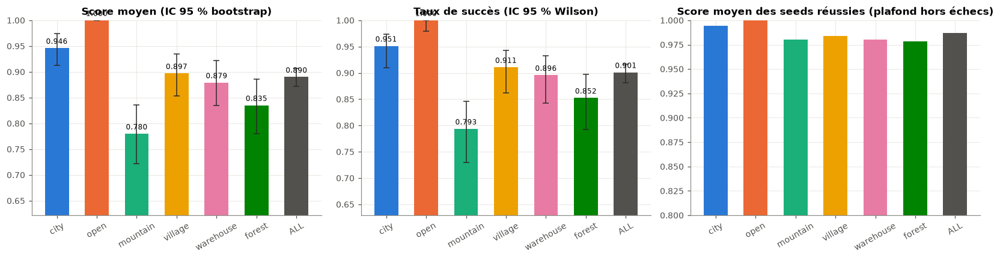

In [3]:
rows = []
for t in TYPES + ["ALL"]:
    g = ep if t == "ALL" else ep[ep["env_type"] == t]
    m, lo, hi = sd.bootstrap_mean_ci(g["score"])
    p, plo, phi = sd.wilson(g["success"].sum(), len(g))
    rows.append(dict(type=t, n=len(g), score=m, s_lo=lo, s_hi=hi, succ=p, p_lo=plo, p_hi=phi,
                     score_si_succes=g.loc[~g["fail"], "score"].mean()))
ov = pd.DataFrame(rows).set_index("type")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
x = np.arange(len(ov))
cols = [TC.get(t, "#52514e") for t in ov.index]
for a, (c, lo, hi, ttl) in zip(ax[:2], [("score", "s_lo", "s_hi", "Score moyen (IC 95 % bootstrap)"),
                                         ("succ", "p_lo", "p_hi", "Taux de succès (IC 95 % Wilson)")]):
    a.bar(x, ov[c], color=cols, width=0.6)
    a.errorbar(x, ov[c], yerr=[ov[c] - ov[lo], ov[hi] - ov[c]], fmt="none", ecolor="#2b2b29", capsize=3, lw=1)
    a.set_xticks(x, ov.index, rotation=30); a.set_title(ttl)
    a.set_ylim(max(0, ov[lo].min() - 0.1), 1.0)
    for xi, v in zip(x, ov[c]): a.text(xi, v + 0.005, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
ax[2].bar(x, ov["score_si_succes"], color=cols, width=0.6)
ax[2].set_xticks(x, ov.index, rotation=30); ax[2].set_ylim(0.8, 1.0)
ax[2].set_title("Score moyen des seeds réussies (plafond hors échecs)")
fig.tight_layout(); save(fig, "01_overview")
ov

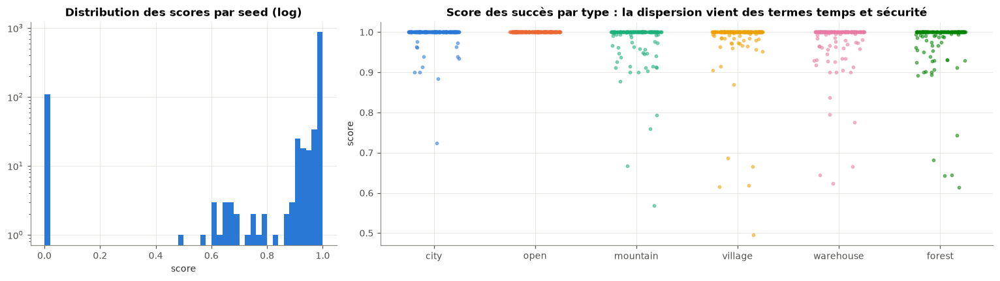

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw=dict(width_ratios=[1, 2]))
ax[0].hist(ep["score"], bins=np.linspace(0, 1, 51), color="#2a78d6")
ax[0].set_yscale("log"); ax[0].set_title("Distribution des scores par seed (log)"); ax[0].set_xlabel("score")
for i, t in enumerate(TYPES):
    s = ep.loc[(ep["env_type"] == t) & ~ep["fail"], "score"]
    ax[1].scatter(np.full(len(s), i) + np.random.uniform(-0.25, 0.25, len(s)), s, s=8, alpha=0.5, color=TC[t])
ax[1].set_xticks(range(len(TYPES)), TYPES); ax[1].set_ylabel("score")
ax[1].set_title("Score des succès par type : la dispersion vient des termes temps et sécurité")
fig.tight_layout(); save(fig, "01_score_dist")

### 1.1 Où partent les points ?

Perte par seed = 1 − score, décomposée en **échec** (0.99 par seed ratée, ou 0.99 si un succès est
annulé par une collision), **temps** (0.45 × (1 − time_term)) et **sécurité** (0.10 × (1 − safety)).
La contribution d'un type à la perte totale est pondérée par sa part de seeds : les barres somment à
1 − score moyen global.

,loss_fail (pts %),loss_time (pts %),loss_safety (pts %),total (pts %)
env_type,,,,
city,0.81,0.04,0.06,0.90
open,0.00,0.00,0.00,0.00
mountain,3.42,0.12,0.14,3.68
village,1.53,0.19,0.06,1.78
warehouse,1.71,0.15,0.14,2.00
forest,2.34,0.15,0.14,2.64


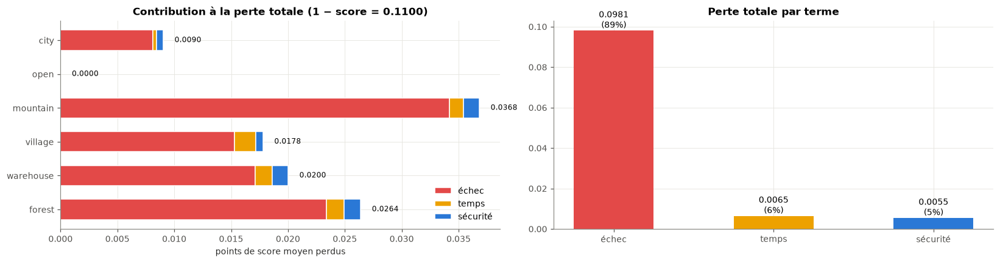

In [5]:
N = len(ep)
loss = ep.groupby("env_type", observed=True)[["loss_fail", "loss_time", "loss_safety"]].sum() / N
loss["total"] = loss.sum(axis=1)
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
left = np.zeros(len(loss))
for c, col, lab in [("loss_fail", "#e34948", "échec"), ("loss_time", "#eda100", "temps"), ("loss_safety", "#2a78d6", "sécurité")]:
    ax[0].barh(loss.index.astype(str), loss[c], left=left, color=col, label=lab, height=0.6, edgecolor="white", linewidth=1)
    left += loss[c].to_numpy()
for i, v in enumerate(loss["total"]): ax[0].text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=8)
ax[0].invert_yaxis(); ax[0].legend(loc="lower right")
ax[0].set_title(f"Contribution à la perte totale (1 − score = {1 - ep['score'].mean():.4f})")
ax[0].set_xlabel("points de score moyen perdus")

tot = loss[["loss_fail", "loss_time", "loss_safety"]].sum()
ax[1].bar(["échec", "temps", "sécurité"], tot, color=["#e34948", "#eda100", "#2a78d6"], width=0.5)
for i, v in enumerate(tot): ax[1].text(i, v, f"{v:.4f}\n({v / tot.sum():.0%})", ha="center", va="bottom")
ax[1].set_title("Perte totale par terme")
fig.tight_layout(); save(fig, "01_loss_breakdown")
(loss * 100).round(2).rename(columns=lambda c: c + " (pts %)")

outcome,success_fast,success_slow,crash,infeasible,to_never_seen,to_seen_not_close,to_close_no_pred,to_pred_unstable,All
env_type,,,,,,,,,
city,173,2,5,0,4,0,0,0,184
open,184,0,0,0,0,0,0,0,184
mountain,141,5,0,1,17,15,5,0,184
village,164,9,1,1,5,7,2,1,190
warehouse,156,7,7,0,2,9,1,0,182
forest,141,9,9,1,1,13,2,0,176
All,959,32,22,3,29,44,10,1,1100


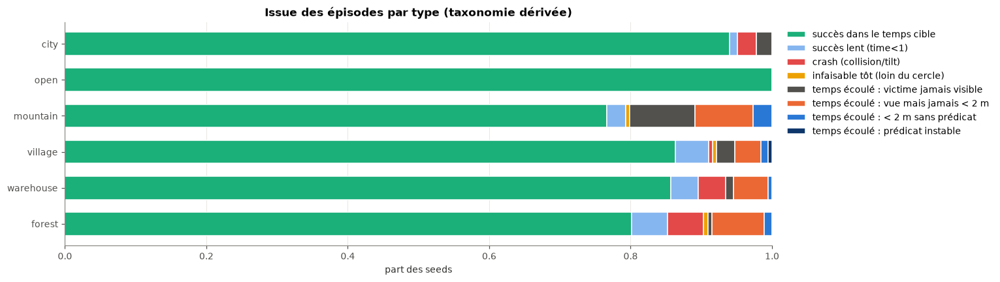

In [6]:
comp = pd.crosstab(ep["env_type"], ep["outcome"], normalize="index").reindex(columns=sd.OUTCOME_ORDER, fill_value=0)
comp = comp.loc[:, comp.sum() > 0]
fig, ax = plt.subplots(figsize=(14, 4))
left = np.zeros(len(comp))
for o in comp.columns:
    ax.barh(comp.index.astype(str), comp[o], left=left, color=OC[o], label=OL[o], height=0.65, edgecolor="white", linewidth=1)
    left += comp[o].to_numpy()
ax.invert_yaxis(); ax.set_xlim(0, 1); ax.set_xlabel("part des seeds")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left"); ax.set_title("Issue des épisodes par type (taxonomie dérivée)")
fig.tight_layout(); save(fig, "01_outcomes")
pd.crosstab(ep["env_type"], ep["outcome"], margins=True).loc[:, lambda d: d.sum() > 0]

> **Lecture (1 100 seeds).** Open est parfait (184/184). La perte totale (11 pts) se répartit en
> mountain 3.7, forest 2.6, warehouse 2.0, village 1.8 et city 0.9. Presque tout vient des échecs
> (rouge). Les succès lents (`success_slow`, 32 seeds) et la sécurité ne coûtent qu'environ 0.6 pt
> chacun.

## 2. Échecs

Taxonomie : `failure_reason` du simulateur, raffinée avec la trajectoire pour les épisodes à court de
temps (victime jamais visible → problème de **recherche** ; vue mais jamais approchée → problème de
**détection/décision** ; approchée sans prédicat → problème de **hover** ; prédicat instable →
problème de **contrôle fin**).

NB : le simulateur ne renvoie presque jamais `TIMEOUT` : `infeasible()` tronque l'épisode dès que
le temps restant ne couvre plus les 2 s de hover, soit t ≈ 58 s pour un drone dans le cercle. Ces
`INFEASIBLE` tardifs sont donc traités comme des timeouts ; seuls ceux tronqués tôt (drone loin du
cercle) restent « infaisable tôt ».

109 échecs / 1100 (9.9%)


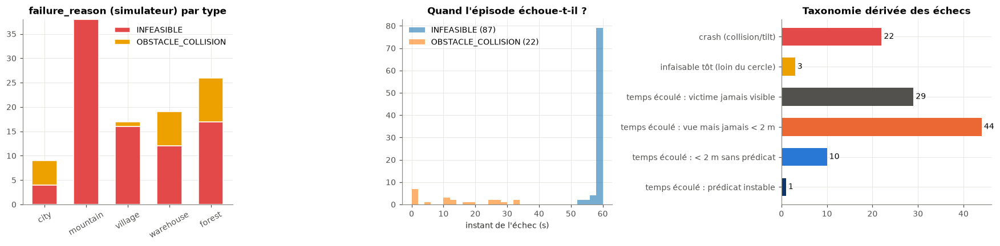

In [7]:
fails = ep[ep["fail"]]
print(f"{len(fails)} échecs / {len(ep)} ({len(fails) / len(ep):.1%})")
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
fr = pd.crosstab(fails["env_type"], fails["failure_reason"])
bottom = np.zeros(len(fr))
palette = ["#e34948", "#eda100", "#52514e", "#e87ba4", "#4a3aa7", "#2a78d6"]
for i, c in enumerate(fr.columns):
    ax[0].bar(fr.index.astype(str), fr[c], bottom=bottom, color=palette[i % len(palette)], label=c, width=0.6, edgecolor="white")
    bottom += fr[c].to_numpy()
ax[0].legend(); ax[0].set_title("failure_reason (simulateur) par type"); ax[0].tick_params(axis="x", rotation=30)

for r, g in fails.groupby("failure_reason"):
    ax[1].hist(g["sim_time"], bins=np.linspace(0, 60, 31), alpha=0.6, label=f"{r} ({len(g)})")
ax[1].set_xlabel("instant de l'échec (s)"); ax[1].legend(); ax[1].set_title("Quand l'épisode échoue-t-il ?")

oc = fails["outcome"].value_counts().reindex(sd.OUTCOME_ORDER).dropna()
oc = oc[oc > 0]
ax[2].barh([OL[o] for o in oc.index], oc.values, color=[OC[o] for o in oc.index], height=0.6)
ax[2].invert_yaxis(); ax[2].set_title("Taxonomie dérivée des échecs")
for i, v in enumerate(oc.values): ax[2].text(v, i, f" {int(v)}", va="center")
fig.tight_layout(); save(fig, "02_failures")

,group,seed,failure_reason,outcome,sim_time,d_start_centre,d_centre_victim,victim_dz_start,first_visible_t,sar_min_hdist,sar_max_dwell,rgb_used
20,type1_city,1000027,OBSTACLE_COLLISION,crash,10.96,85.561,20.460,-0.070,NaN,53.112,0.00,0
43,type1_city,1000054,OBSTACLE_COLLISION,crash,11.02,24.102,21.825,0.230,11.0,24.812,0.00,0
790,type1_city,1000729,OBSTACLE_COLLISION,crash,27.48,58.164,29.232,-2.309,NaN,29.328,0.00,0
938,type1_city,1000909,OBSTACLE_COLLISION,crash,19.90,48.962,14.366,-3.151,NaN,17.206,0.00,0
1067,type1_city,1001058,OBSTACLE_COLLISION,crash,32.48,59.323,29.283,-2.797,26.7,14.011,0.00,0
256,type4_village,1000304,OBSTACLE_COLLISION,crash,5.08,8.448,10.866,0.728,NaN,7.303,0.00,0
71,type5_warehouse,1000059,OBSTACLE_COLLISION,crash,0.32,51.747,21.933,1.634,NaN,30.676,0.00,0
209,type5_warehouse,1000193,OBSTACLE_COLLISION,crash,0.32,14.987,28.596,1.634,NaN,43.398,0.00,0
407,type5_warehouse,1000397,OBSTACLE_COLLISION,crash,0.32,54.429,27.197,1.634,NaN,27.688,0.00,0
455,type5_warehouse,1000448,OBSTACLE_COLLISION,crash,0.36,11.198,1.066,1.634,NaN,11.415,0.00,0


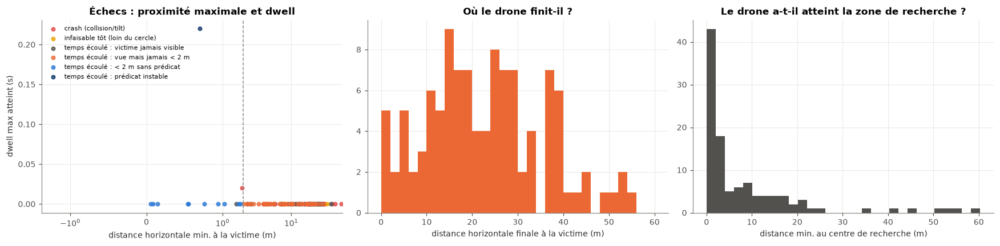

In [8]:
# Échecs : à quelle distance de la victime le drone a-t-il fini, et s'en est-il approché ?
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for o, g in fails.groupby("outcome", observed=True):
    ax[0].scatter(g["sar_min_hdist"], g["sar_max_dwell"], s=18, color=OC[o], label=OL[o], alpha=0.8)
ax[0].axvline(2, color="#8a8984", ls="--", lw=1); ax[0].set_xscale("symlog", linthresh=1)
ax[0].set_xlabel("distance horizontale min. à la victime (m)"); ax[0].set_ylabel("dwell max atteint (s)")
ax[0].set_title("Échecs : proximité maximale et dwell"); ax[0].legend(fontsize=7)

if HAS_TRAJ:
    fx = epx[epx["fail"]]
    ax[1].hist([fx.loc[fx["success"] == False, "final_hdist"]], bins=np.linspace(0, 60, 31), color="#eb6834")
    ax[1].set_xlabel("distance horizontale finale à la victime (m)"); ax[1].set_title("Où le drone finit-il ?")
    ax[2].hist(fx["min_d_centre"], bins=30, color="#52514e")
    ax[2].set_xlabel("distance min. au centre de recherche (m)")
    ax[2].set_title("Le drone a-t-il atteint la zone de recherche ?")
fig.tight_layout(); save(fig, "02_fail_geometry")

show = ["group", "seed", "failure_reason", "outcome", "sim_time", "d_start_centre", "d_centre_victim",
        "victim_dz_start", "first_visible_t", "sar_min_hdist", "sar_max_dwell", "rgb_used"]
fails.sort_values(["outcome", "env_type"])[[c for c in show if c in fails]].head(60)

> **Lecture.** 109 échecs. Les timeouts dominent : vue sans approche 44, jamais vue 29, < 2 m sans
> prédicat 10, prédicat instable 1. Viennent ensuite 22 crashs et 3 infaisables tôt.
> - Les **crashs warehouse (7)** surviennent tous à **t = 0.32–0.36 s**, au décollage
>   (voir 16.2). Les crashs forest (9) et city (5) ont lieu en vol, entre 11 et 34 s.
> - Pour les timeouts « jamais vue », le drone a bien atteint le centre (distance min. médiane
>   1.3 m) : le problème est le **balayage**, pas la navigation.

## 3. Terme temps

`target_time = 1.03 × (d(start, centre)/3 + 27.5 + 2)`. Toute seconde au-delà coûte
0.45 / (60 − target) points. On décompose chaque succès en phases :
transit → entrée dans le cercle → première visibilité géométrique → < 2 m → prédicat → confirmation.

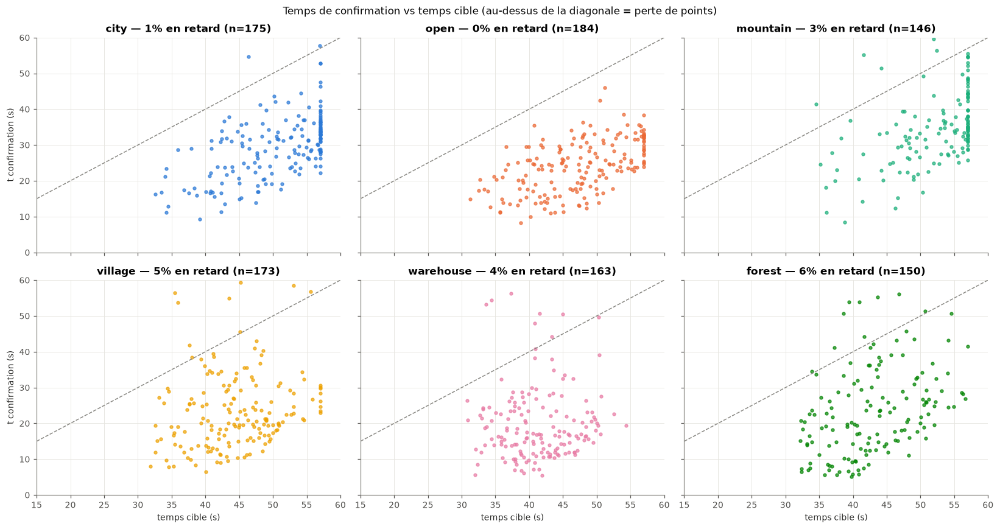

In [9]:
succ = epx[~epx["fail"]].copy()
fig, axs = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
for a, t in zip(axs.flat, T):
    g = succ[succ["env_type"] == t]
    a.scatter(g["target_time"], g["t_confirm_eff"], s=10, color=TC[t], alpha=0.7)
    lim = [15, 60]; a.plot(lim, lim, color="#8a8984", lw=1, ls="--")
    late = (g["t_confirm_eff"] > g["target_time"]).mean() if len(g) else np.nan
    a.set_title(f"{t} — {late:.0%} en retard (n={len(g)})")
    a.set_xlim(*lim); a.set_ylim(0, 60)
for a in axs[-1]: a.set_xlabel("temps cible (s)")
for a in axs[:, 0]: a.set_ylabel("t confirmation (s)")
fig.suptitle("Temps de confirmation vs temps cible (au-dessus de la diagonale = perte de points)")
fig.tight_layout(); save(fig, "03_time_vs_target")

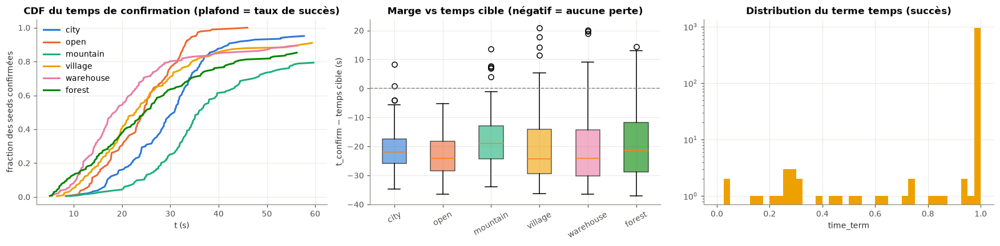

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for t in TYPES:
    g = np.sort(succ.loc[succ["env_type"] == t, "t_confirm_eff"].dropna())
    if len(g): ax[0].plot(g, np.arange(1, len(g) + 1) / len(ep[ep["env_type"] == t]), color=TC[t], label=t)
ax[0].set_xlabel("t (s)"); ax[0].set_ylabel("fraction des seeds confirmées"); ax[0].set_title("CDF du temps de confirmation (plafond = taux de succès)")
ax[0].legend()
data = [succ.loc[succ["env_type"] == t, "excess_time"].dropna() for t in TYPES]
bp = ax[1].boxplot(data, tick_labels=TYPES, showfliers=True, patch_artist=True, widths=0.5)
for p, t in zip(bp["boxes"], TYPES): p.set_facecolor(TC[t]); p.set_alpha(0.6)
ax[1].axhline(0, color="#8a8984", ls="--", lw=1); ax[1].set_ylabel("t_confirm − temps cible (s)")
ax[1].set_title("Marge vs temps cible (négatif = aucune perte)"); ax[1].tick_params(axis="x", rotation=30)
ax[2].hist(succ["time_term"], bins=np.linspace(0, 1, 41), color="#eda100")
ax[2].set_yscale("log"); ax[2].set_xlabel("time_term"); ax[2].set_title("Distribution du terme temps (succès)")
fig.tight_layout(); save(fig, "03_time_dist")

env_type                        city   open  mountain  village  warehouse  forest
transit → cercle        count  174.0  184.0     146.0    173.0      163.0   149.0
                        mean    14.6   11.1      18.3      7.5        4.4     7.2
                        std      8.8    8.1       9.8      6.4        5.1     8.2
                        min      0.0    0.0       0.0      0.0        0.0     0.0
                        25%      8.1    4.6      11.9      0.0        0.0     0.0
                        50%     14.4   10.8      18.1      6.8        2.5     4.8
                        75%     20.5   16.6      24.8     11.6        7.9    12.1
                        max     34.1   31.8      46.3     24.2       19.6    37.3
cercle → 1re visibilité count  175.0  184.0     145.0    173.0      163.0   150.0
                        mean     1.7    0.6       1.8      3.4        1.3     3.4
                        std      7.9    7.4       7.1     10.2        7.5    10.1
                        min    -12.2  -12.3     -10.4    -12.7      -12.1   -14.3
                        25%     -4.1   -5.7      -3.2     -3.8       -5.0    -3.4
                        50%      0.2    0.1       1.3      1.1        0.4     1.3
                        75%      6.9    6.7       5.7      9.0        6.1     7.9
                        max     25.8   20.7      23.4     41.2       24.7    38.1
visible → < 2 m         count  175.0  184.0     145.0    173.0      163.0   150.0
                        mean    10.6    9.9      11.9      9.7       11.4     9.9
                        std      2.4    1.7       6.3      5.3        8.0     7.2
                        min      2.7   -8.7       1.4    -12.8      -10.6   -34.6
                        25%     10.0    9.9       9.8      7.4        8.1     7.0
                        50%     10.2   10.1      10.1      9.9        9.9    10.1
                        75%     11.0   10.4      11.9     10.2       11.0    11.5
                        max     32.7   12.4      45.9     43.9       52.0    40.3
< 2 m → prédicat        count  175.0  184.0     146.0    173.0      163.0   150.0
                        mean     0.5    0.6       0.4      0.8        0.7     1.1
                        std      0.2    1.3       0.3      2.0        2.0     4.5
                        min      0.2    0.2       0.0      0.1        0.2     0.1
                        25%      0.4    0.4       0.2      0.4        0.3     0.4
                        50%      0.4    0.4       0.4      0.4        0.4     0.5
                        75%      0.5    0.4       0.6      0.5        0.5     0.6
                        max      2.6   16.1       2.3     23.7       20.6    51.8
prédicat → confirmation count  175.0  184.0     146.0    173.0      163.0   150.0
                        mean     2.0    2.0       2.0      2.0        2.0     2.0
                        std      0.0    0.0       0.6      0.0        0.0     0.0
                        min      2.0    2.0       2.0      2.0        2.0     2.0
                        25%      2.0    2.0       2.0      2.0        2.0     2.0
                        50%      2.0    2.0       2.0      2.0        2.0     2.0
                        75%      2.0    2.0       2.0      2.0        2.0     2.0
                        max      2.0    2.0       9.3      2.0        2.0     2.0

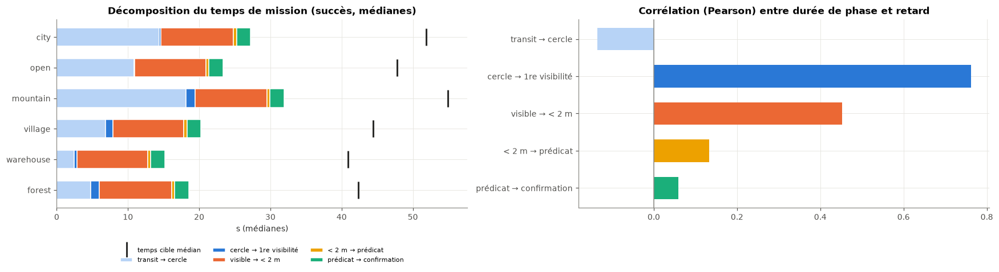

In [11]:
if HAS_TRAJ:
    ph = pd.DataFrame({
        "env_type": succ["env_type"],
        "transit → cercle": succ["t_reach_circle"],
        "cercle → 1re visibilité": succ["t_first_vis"] - succ["t_reach_circle"].fillna(0),
        "visible → < 2 m": succ["t_first_2m"] - succ["t_first_vis"],
        "< 2 m → prédicat": succ["t_first_pred"] - succ["t_first_2m"],
        "prédicat → confirmation": succ["t_confirm_eff"] - succ["t_first_pred"],
    })
    phases = ph.columns[1:]
    med = ph.groupby("env_type", observed=True)[list(phases)].median().clip(lower=0)
    fig, ax = plt.subplots(1, 2, figsize=(16, 4.5))
    left = np.zeros(len(med))
    pcol = ["#b7d3f6", "#2a78d6", "#eb6834", "#eda100", "#1baf7a"]
    for c, col in zip(phases, pcol):
        ax[0].barh(med.index.astype(str), med[c], left=left, color=col, label=c, height=0.6, edgecolor="white")
        left += med[c].to_numpy()
    tt_med = succ.groupby("env_type", observed=True)["target_time"].median()
    ax[0].scatter(tt_med.values, np.arange(len(tt_med)), marker="|", s=400, color="#2b2b29", label="temps cible médian", zorder=3)
    ax[0].invert_yaxis(); ax[0].legend(fontsize=7, bbox_to_anchor=(0.5, -0.18), loc="upper center", ncol=3); ax[0].set_xlabel("s (médianes)")
    ax[0].set_title("Décomposition du temps de mission (succès, médianes)")
    # quelle phase explique le retard ? corrélation phase ↔ excès de temps
    corr = ph[phases].apply(lambda c: c.corr(succ["excess_time"]))
    ax[1].barh(list(phases), corr.values, color=pcol, height=0.6)
    ax[1].axvline(0, color="#8a8984", lw=1); ax[1].invert_yaxis()
    ax[1].set_title("Corrélation (Pearson) entre durée de phase et retard")
    fig.tight_layout(); save(fig, "03_phases")
    display(ph.groupby("env_type", observed=True)[list(phases)].describe().T.round(1))

> **Lecture.** Pour les succès, la confirmation suit presque toujours le même déroulé : prédicat
> obtenu 0.4 s après le passage sous 2 m, puis exactement 2.0 s de hover. La phase
> « visible → < 2 m » dure environ **10 s dans tous les types** : la victime devient visible à
> 24–29 m et le drone s'approche à 2–2.7 m/s. Cette phase est donc limitée par la vitesse de
> déplacement. Le terme temps ne coûte que 0.65 pt : le gain possible y est faible.

## 4. Terme sécurité (clearance minimale)

,perte_moy,frac_pénalisé
env_type,,
city,0.004,0.063
open,0.000,0.000
mountain,0.011,0.226
village,0.004,0.150
warehouse,0.009,0.221
forest,0.011,0.253


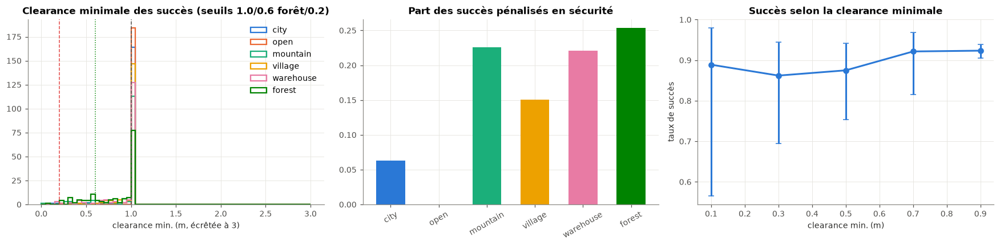

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
bins = np.linspace(0, 3, 61)
for t in TYPES:
    g = ep.loc[(ep["env_type"] == t) & ~ep["fail"], "min_clearance"].dropna()
    ax[0].hist(g.clip(upper=3), bins=bins, histtype="step", color=TC[t], label=t, lw=1.5)
ax[0].axvline(1.0, color="#52514e", ls="--", lw=1); ax[0].axvline(0.6, color="#008300", ls=":", lw=1)
ax[0].axvline(0.2, color="#e34948", ls="--", lw=1)
ax[0].set_xlabel("clearance min. (m, écrêtée à 3)"); ax[0].legend(); ax[0].set_title("Clearance minimale des succès (seuils 1.0/0.6 forêt/0.2)")
sl = ep[~ep["fail"]].groupby("env_type", observed=True).agg(
    perte_moy=("loss_safety", "mean"), frac_pénalisé=("safety_term", lambda s: (s < 1).mean()))
ax[1].bar(sl.index.astype(str), sl["frac_pénalisé"], color=[TC[t] for t in sl.index], width=0.6)
ax[1].set_title("Part des succès pénalisés en sécurité"); ax[1].tick_params(axis="x", rotation=30)
x = ep["min_clearance"].clip(upper=3)
br = sd.binned_rate(x, ~ep["fail"], np.array([0, .2, .4, .6, .8, 1, 1.5, 2, 3.01]))
ax[2].errorbar(br["mid"], br["rate"], yerr=[br["rate"] - br["lo"], br["hi"] - br["rate"]], marker="o", color="#2a78d6", capsize=3)
ax[2].set_xlabel("clearance min. (m)"); ax[2].set_ylabel("taux de succès"); ax[2].set_title("Succès selon la clearance minimale")
fig.tight_layout(); save(fig, "04_safety")
sl

> **Lecture.** La sécurité coûte 0.55 pt. Environ 22–25 % des succès sont pénalisés en mountain,
> warehouse et forest, 6 % en city et aucun en open. La pénalité par seed est petite (≈ 0.01) :
> ce n'est pas une priorité.

## 5. Facteurs géométriques

Taux de succès (IC Wilson) en fonction des paramètres de la tâche, tous connus avant l'épisode. Un
facteur fortement prédictif indique un sous-cas que l'agent gère mal.

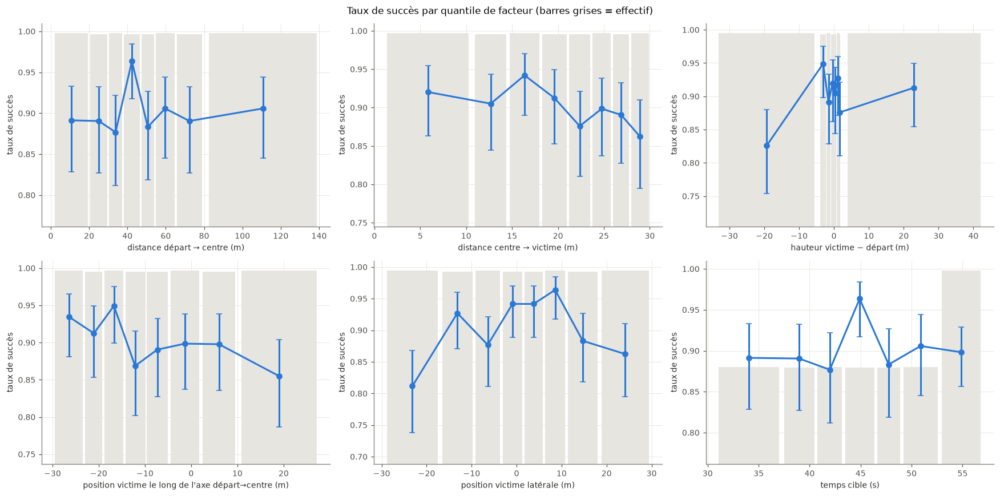

In [13]:
facts = [("d_start_centre", "distance départ → centre (m)", 8),
         ("d_centre_victim", "distance centre → victime (m)", 8),
         ("victim_dz_start", "hauteur victime − départ (m)", 8),
         ("victim_along", "position victime le long de l'axe départ→centre (m)", 8),
         ("victim_across", "position victime latérale (m)", 8),
         ("target_time", "temps cible (s)", 8)]
facts = [f for f in facts if f[0] in ep]
fig, axs = plt.subplots(2, 3, figsize=(16, 8))
for a, (c, lab, nb) in zip(axs.flat, facts):
    x = ep[c].astype(float)
    bins = np.unique(np.nanquantile(x, np.linspace(0, 1, nb + 1)))
    bins[0] -= 1e-6
    br = sd.binned_rate(x, ~ep["fail"], bins)
    a.errorbar(br["mid"], br["rate"], yerr=[br["rate"] - br["lo"], br["hi"] - br["rate"]], marker="o", color="#2a78d6", capsize=3)
    a2 = a.twinx(); a2.bar(br["mid"].astype(float), br["n"], width=[iv.length * 0.9 for iv in br["bin"]], color="#e6e5e0", zorder=0); a2.set_yticks([])
    a.set_zorder(a2.get_zorder() + 1); a.patch.set_visible(False)
    a.set_xlabel(lab); a.set_ylabel("taux de succès"); a.set_ylim(max(0, br["lo"].min() - 0.05), 1.01)
fig.suptitle("Taux de succès par quantile de facteur (barres grises = effectif)")
fig.tight_layout(); save(fig, "05_factors")

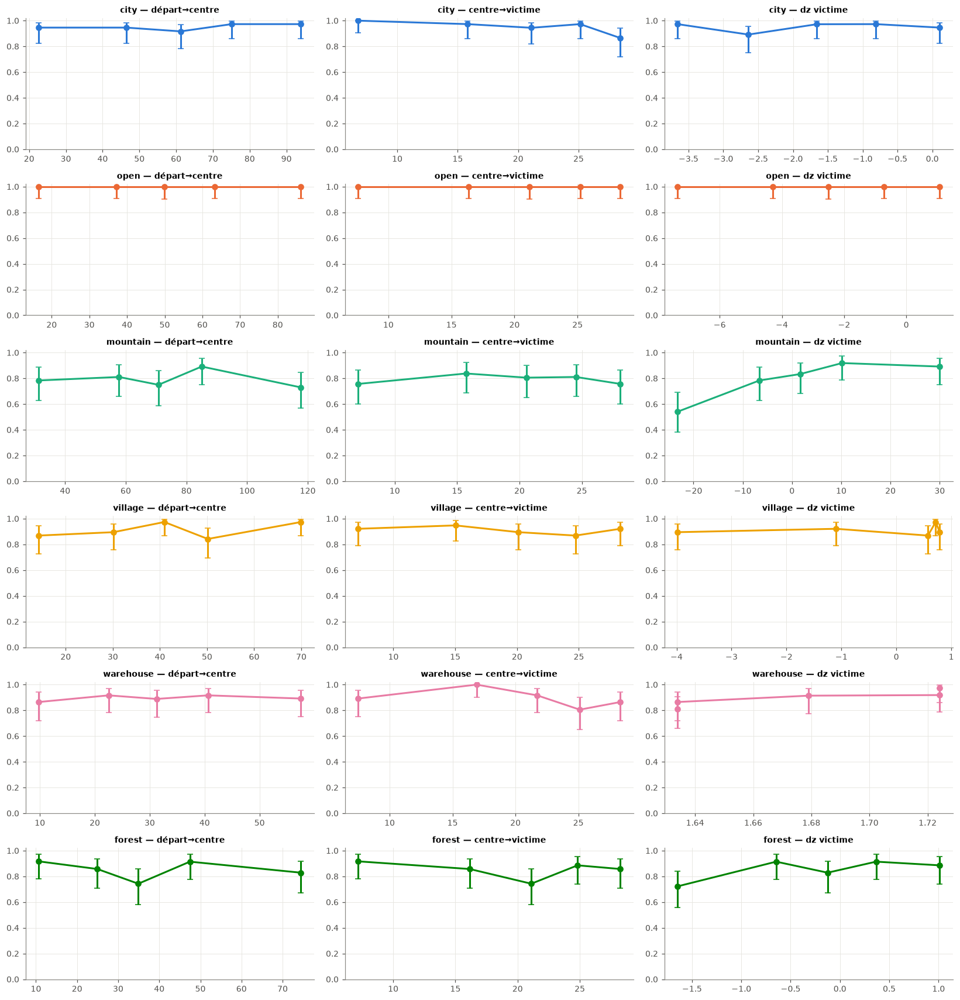

In [14]:
# Mêmes facteurs, par type d'environnement (la géométrie diffère beaucoup d'un type à l'autre)
fig, axs = plt.subplots(len(TYPES), 3, figsize=(15, 2.6 * len(TYPES)), squeeze=False)
for i, t in enumerate(TYPES):
    g = ep[ep["env_type"] == t]
    for j, (c, lab) in enumerate([("d_start_centre", "départ→centre"), ("d_centre_victim", "centre→victime"), ("victim_dz_start", "dz victime")]):
        a = axs[i, j]
        if c not in g: continue
        x = g[c].astype(float)
        bins = np.unique(np.nanquantile(x, np.linspace(0, 1, 6))); bins[0] -= 1e-6
        br = sd.binned_rate(x, ~g["fail"], bins)
        a.errorbar(br["mid"], br["rate"], yerr=[br["rate"] - br["lo"], br["hi"] - br["rate"]], marker="o", color=TC[t], capsize=3)
        a.set_ylim(0, 1.02); a.set_title(f"{t} — {lab}", fontsize=9)
fig.tight_layout(); save(fig, "05_factors_by_type")

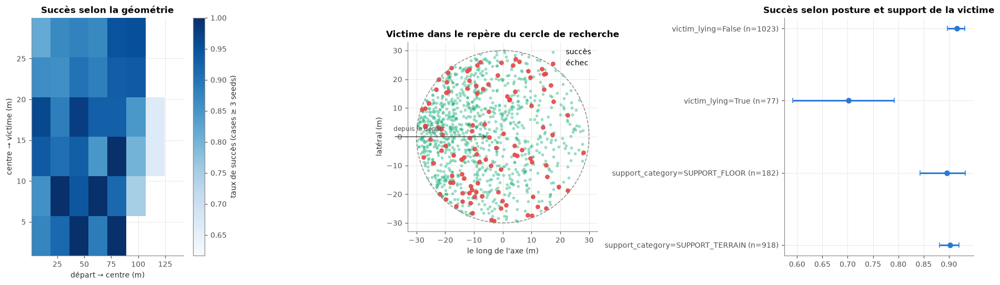

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(17, 5))
# carte 2D : succès selon (départ→centre, centre→victime)
H_all, xe, ye = np.histogram2d(ep["d_start_centre"], ep["d_centre_victim"], bins=[8, 6])
H_ok, _, _ = np.histogram2d(ep.loc[~ep["fail"], "d_start_centre"], ep.loc[~ep["fail"], "d_centre_victim"], bins=[xe, ye])
rate = np.where(H_all >= 3, H_ok / np.maximum(H_all, 1), np.nan)
im = ax[0].pcolormesh(xe, ye, rate.T, cmap="Blues", vmin=max(0, np.nanmin(rate) - 0.05) if np.isfinite(rate).any() else 0, vmax=1)
fig.colorbar(im, ax=ax[0], label="taux de succès (cases ≥ 3 seeds)")
ax[0].set_xlabel("départ → centre (m)"); ax[0].set_ylabel("centre → victime (m)"); ax[0].set_title("Succès selon la géométrie")
# position de la victime dans le repère (centre, axe départ→centre)
if "victim_along" in ep:
    for ok, col, lab in [(True, SUCC_C, "succès"), (False, FAIL_C, "échec")]:
        g = ep[(~ep["fail"]) == ok]
        ax[1].scatter(g["victim_along"], g["victim_across"], s=8 if ok else 22, color=col, alpha=0.35 if ok else 0.9, label=lab)
    ax[1].add_patch(Circle((0, 0), 30, fill=False, ls="--", color="#8a8984"))
    ax[1].annotate("", xy=(-5, 0), xytext=(-38, 0), arrowprops=dict(arrowstyle="->", color="#52514e"))
    ax[1].text(-38, 2, "depuis le départ", fontsize=8, color="#52514e")
    ax[1].set_aspect("equal"); ax[1].legend(); ax[1].set_title("Victime dans le repère du cercle de recherche")
    ax[1].set_xlabel("le long de l'axe (m)"); ax[1].set_ylabel("latéral (m)")
# posture / support
cats = [c for c in ["victim_lying", "support_category"] if c in ep]
rows = []
for c in cats:
    for v, g in ep.groupby(c):
        p, lo, hi = sd.wilson((~g["fail"]).sum(), len(g))
        rows.append((f"{c}={v}", p, lo, hi, len(g)))
if rows:
    r = pd.DataFrame(rows, columns=["k", "p", "lo", "hi", "n"])
    ax[2].errorbar(r["p"], np.arange(len(r)), xerr=[r["p"] - r["lo"], r["hi"] - r["p"]], fmt="o", color="#2a78d6", capsize=3)
    ax[2].set_yticks(np.arange(len(r)), [f"{k} (n={n})" for k, n in zip(r["k"], r["n"])]); ax[2].invert_yaxis()
    ax[2].set_title("Succès selon posture et support de la victime")
fig.tight_layout(); save(fig, "05_geometry_maps")

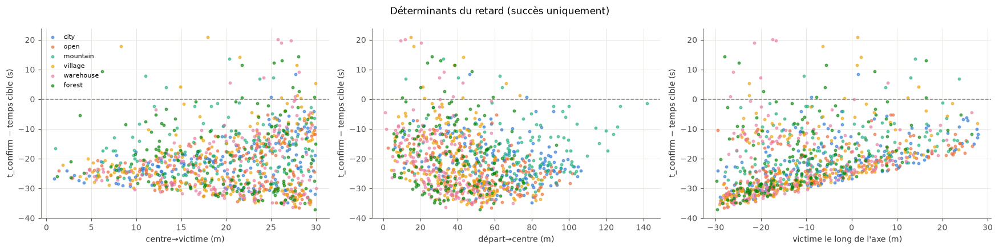

In [16]:
# Pour les succès : ce qui coûte du temps
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, c, lab in zip(ax, ["d_centre_victim", "d_start_centre", "victim_along"], ["centre→victime (m)", "départ→centre (m)", "victime le long de l'axe (m)"]):
    if c not in succ: continue
    for t in TYPES:
        g = succ[succ["env_type"] == t]
        a.scatter(g[c], g["excess_time"], s=8, color=TC[t], alpha=0.6, label=t)
    a.axhline(0, color="#8a8984", ls="--", lw=1); a.set_xlabel(lab); a.set_ylabel("t_confirm − temps cible (s)")
ax[0].legend(fontsize=7); fig.suptitle("Déterminants du retard (succès uniquement)")
fig.tight_layout(); save(fig, "05_time_drivers")

> **Lecture.** Les facteurs connus avant l'épisode prédisent mal l'échec. Par quartile, le taux de
> succès reste entre 88 et 93 % pour les distances départ→centre et centre→victime et pour le
> dénivelé. Il baisse légèrement quand la victime est en bord de cercle (> 21 m du centre :
> 88 % contre 92 %). Le seul facteur fort est la **posture** : une victime allongée réussit à
> 70 % contre 92 % (voir 16.1).

## 6. Perception et couverture de la recherche

`vis` = vérité terrain géométrique (victime dans le champ, < 30 m, non occultée), calculée tous les
5 pas. La **couverture** est un proxy : fraction du disque de recherche passée à moins de 10 m du
drone.

vue       False       True       
succès    False True  False True 
env_type                         
city          7     0     2   175
open          0     0     0   184
mountain     18     1    20   145
village       7     0    10   173
warehouse     9     0    10   163
forest        3     0    23   150

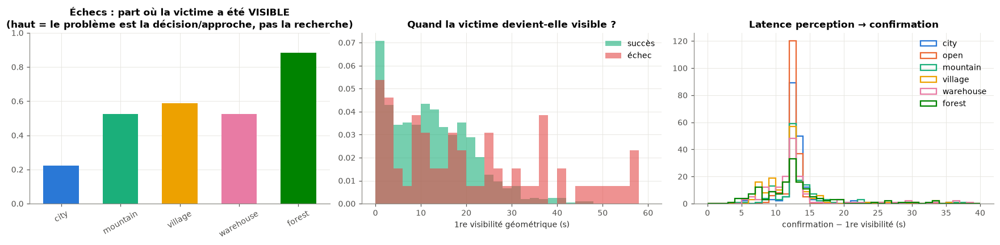

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
seen = ep["first_visible_t"].notna()
tab = pd.crosstab(ep["env_type"], [seen.rename("vue"), (~ep["fail"]).rename("succès")])
fr_seen_fail = (ep[ep["fail"]].assign(seen=seen).groupby("env_type", observed=True)["seen"].mean())
ax[0].bar(fr_seen_fail.index.astype(str), fr_seen_fail.values, color=[TC[t] for t in fr_seen_fail.index], width=0.6)
ax[0].set_ylim(0, 1); ax[0].set_title("Échecs : part où la victime a été VISIBLE\n(haut = le problème est la décision/approche, pas la recherche)")
ax[0].tick_params(axis="x", rotation=30)
for ok, col, lab in [(True, SUCC_C, "succès"), (False, FAIL_C, "échec")]:
    g = ep.loc[((~ep["fail"]) == ok) & seen, "first_visible_t"]
    ax[1].hist(g, bins=np.linspace(0, 60, 31), alpha=0.6, color=col, label=lab, density=True)
ax[1].legend(); ax[1].set_xlabel("1re visibilité géométrique (s)"); ax[1].set_title("Quand la victime devient-elle visible ?")
s2 = ep[~ep["fail"] & seen]
lat = s2["t_confirm_eff"] - s2["first_visible_t"]
for t in TYPES:
    v = lat[s2["env_type"] == t]
    if len(v): ax[2].hist(v, bins=np.linspace(0, 40, 41), histtype="step", color=TC[t], label=t, lw=1.5)
ax[2].set_xlabel("confirmation − 1re visibilité (s)"); ax[2].legend(); ax[2].set_title("Latence perception → confirmation")
fig.tight_layout(); save(fig, "06_visibility")
tab

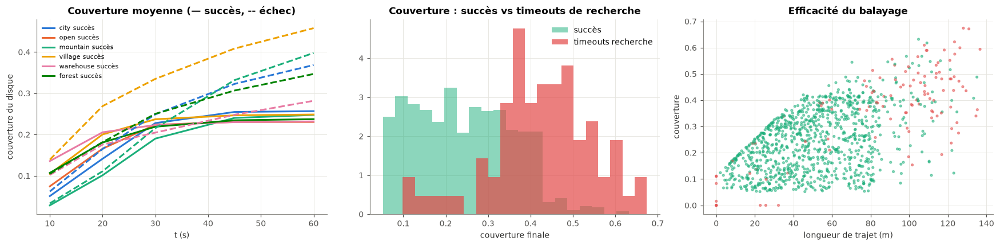

In [18]:
if HAS_TRAJ:
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    ts = [10, 20, 30, 45, 60]
    for ok, ls, lab in [(True, "-", "succès"), (False, "--", "échec")]:
        for t in TYPES:
            g = epx[(epx["env_type"] == t) & ((~epx["fail"]) == ok)]
            if len(g) >= 1:
                ax[0].plot(ts, [g[f"coverage_{k}s"].mean() for k in ts], ls=ls, color=TC[t], label=f"{t} {lab}" if ok else None)
    ax[0].set_xlabel("t (s)"); ax[0].set_ylabel("couverture du disque"); ax[0].set_title("Couverture moyenne (— succès, -- échec)")
    ax[0].legend(fontsize=7)
    tn = epx[epx["outcome"].isin(["to_never_seen", "to_seen_not_close"])]
    ax[1].hist(epx.loc[~epx["fail"], "coverage"], bins=20, alpha=0.5, color=SUCC_C, label="succès", density=True)
    if len(tn): ax[1].hist(tn["coverage"], bins=20, alpha=0.7, color=FAIL_C, label="timeouts recherche", density=True)
    ax[1].set_xlabel("couverture finale"); ax[1].legend(); ax[1].set_title("Couverture : succès vs timeouts de recherche")
    ax[2].scatter(epx["path_len_traj"], epx["coverage"], s=6, c=np.where(epx["fail"], FAIL_C, SUCC_C), alpha=0.5)
    ax[2].set_xlabel("longueur de trajet (m)"); ax[2].set_ylabel("couverture"); ax[2].set_title("Efficacité du balayage")
    fig.tight_layout(); save(fig, "06_coverage")

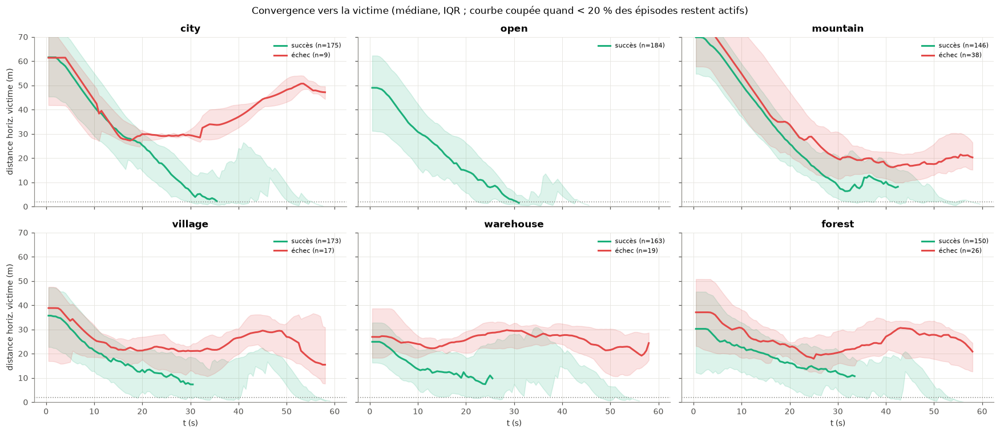

In [19]:
# Distance horizontale à la victime au cours du temps (médiane + IQR), succès vs échecs, par type
if HAS_TRAJ:
    grid = np.arange(0, 60.01, 0.5)
    B = sd.series_bundle(RUN_A, ep, ["hdist", "h_above", "speed", "agl", "vis"], grid)
    fig, axs = plt.subplots(2, 3, figsize=(16, 7), sharex=True, sharey=True)
    for a, t in zip(axs.flat, T):
        for ok, col, lab in [(True, SUCC_C, "succès"), (False, FAIL_C, "échec")]:
            m = ((ep["env_type"] == t) & ((~ep["fail"]) == ok)).to_numpy()
            if m.sum() < 1: continue
            H = B["hdist"].to_numpy()[m]
            med, q1, q3 = np.nanmedian(H, 0), np.nanpercentile(H, 25, 0), np.nanpercentile(H, 75, 0)
            alive = np.isfinite(H).mean(0)
            med[alive < 0.2] = np.nan
            a.plot(grid, med, color=col, label=f"{lab} (n={m.sum()})"); a.fill_between(grid, q1, q3, color=col, alpha=0.15)
        a.axhline(2, color="#8a8984", ls=":", lw=1); a.set_title(t); a.legend(fontsize=7); a.set_ylim(0, 70)
    for a in axs[-1]: a.set_xlabel("t (s)")
    for a in axs[:, 0]: a.set_ylabel("distance horiz. victime (m)")
    fig.suptitle("Convergence vers la victime (médiane, IQR ; courbe coupée quand < 20 % des épisodes restent actifs)")
    fig.tight_layout(); save(fig, "06_hdist_time")

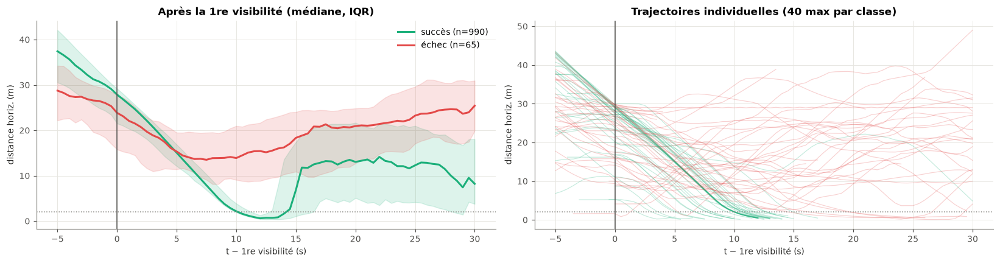

In [20]:
# Aligné sur la 1re visibilité : une fois la victime visible, le drone converge-t-il ?
if HAS_TRAJ:
    grid_v = np.arange(-5, 30.01, 0.5)
    BV = sd.series_bundle(RUN_A, epx, ["hdist"], grid_v, align="t_first_vis")
    fig, ax = plt.subplots(1, 2, figsize=(15, 4))
    for ok, col, lab in [(True, SUCC_C, "succès"), (False, FAIL_C, "échec")]:
        m = ((~epx["fail"]) == ok).to_numpy() & epx["t_first_vis"].notna().to_numpy()
        H = BV["hdist"].to_numpy()[m]
        if m.sum() < 1: continue
        ax[0].plot(grid_v, np.nanmedian(H, 0), color=col, label=f"{lab} (n={m.sum()})")
        ax[0].fill_between(grid_v, np.nanpercentile(H, 25, 0), np.nanpercentile(H, 75, 0), color=col, alpha=0.15)
        for row in H[:40]: ax[1].plot(grid_v, row, color=col, alpha=0.25, lw=0.8)
    for a in ax:
        a.axvline(0, color="#52514e", lw=1); a.axhline(2, color="#8a8984", ls=":", lw=1)
        a.set_xlabel("t − 1re visibilité (s)"); a.set_ylabel("distance horiz. (m)")
    ax[0].legend(); ax[0].set_title("Après la 1re visibilité (médiane, IQR)"); ax[1].set_title("Trajectoires individuelles (40 max par classe)")
    fig.tight_layout(); save(fig, "06_after_first_vis")

> **Lecture.** Le « vue mais jamais approchée » est le gisement principal (44 seeds). La victime
> est visible au total 4.7 s seulement (médiane), avec 21 px au maximum (contre 47 pour les
> succès), et le drone ne passe jamais à moins de 11.7 m d'elle pendant qu'elle est visible. Elle
> sort du champ avant que la politique ne s'engage. Les épisodes en échec couvrent davantage le
> disque (0.39 contre 0.24) : le drone cherche longtemps et a déjà « vu » la cible. Il faudrait
> **mémoriser la dernière détection** pour y revenir.

## 7. Phase finale : approche et hover de confirmation

Le prédicat exige simultanément distance horizontale ≤ 2 m, hauteur 2–4 m au-dessus du haut de la
boîte englobante, vitesse ≤ 1 m/s, pendant 2 s. Quelle condition bloque ?

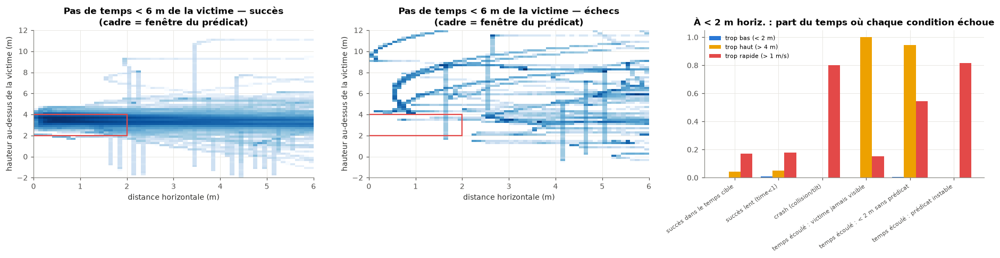

In [21]:
if HAS_TRAJ:
    fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
    for a, ok, ttl in [(ax[0], True, "succès"), (ax[1], False, "échecs")]:
        hs, zs = [], []
        for _, r in epx[(~epx["fail"]) == ok].iterrows():
            tr = sd.load_traj(RUN_A, r["group"], r["seed"])
            if tr is None: continue
            m = tr["hdist"] < 6
            hs.append(tr["hdist"][m]); zs.append(tr["h_above"][m])
        if hs:
            h, z = np.concatenate(hs), np.concatenate(zs)
            a.hist2d(h, z, bins=[np.linspace(0, 6, 61), np.linspace(-2, 12, 71)], cmap="Blues", norm=mpl.colors.LogNorm())
        a.add_patch(Rectangle((0, 2), 2, 2, fill=False, ec=FAIL_C, lw=1.5))
        a.set_xlabel("distance horizontale (m)"); a.set_ylabel("hauteur au-dessus de la victime (m)")
        a.set_title(f"Pas de temps < 6 m de la victime — {ttl}\n(cadre = fenêtre du prédicat)")
    nf = epx.groupby("outcome", observed=True)[["near_fail_low", "near_fail_high", "near_fail_fast"]].mean().dropna(how="all")
    xx = np.arange(len(nf)); w = 0.27
    for k, (c, col, lab) in enumerate([("near_fail_low", "#2a78d6", "trop bas (< 2 m)"), ("near_fail_high", "#eda100", "trop haut (> 4 m)"), ("near_fail_fast", "#e34948", "trop rapide (> 1 m/s)")]):
        ax[2].bar(xx + (k - 1) * w, nf[c], width=w, color=col, label=lab)
    ax[2].set_xticks(xx, [OL[o] for o in nf.index], rotation=35, ha="right", fontsize=7)
    ax[2].legend(fontsize=7); ax[2].set_title("À < 2 m horiz. : part du temps où chaque condition échoue")
    fig.tight_layout(); save(fig, "07_hover_window")

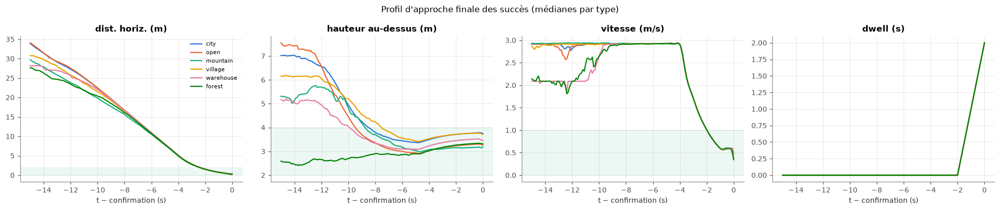

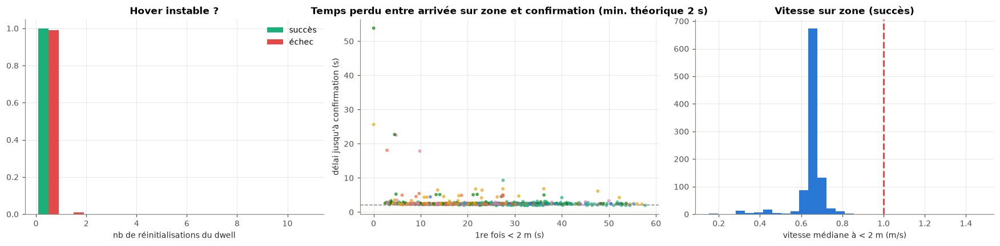

In [22]:
if HAS_TRAJ:
    grid_c = np.arange(-15, 0.01, 0.1)
    BC = sd.series_bundle(RUN_A, succ, ["hdist", "h_above", "speed", "dwell"], grid_c, align="t_confirm_eff")
    fig, axs = plt.subplots(1, 4, figsize=(18, 3.8))
    for a, c, lab, band in zip(axs, ["hdist", "h_above", "speed", "dwell"],
                               ["dist. horiz. (m)", "hauteur au-dessus (m)", "vitesse (m/s)", "dwell (s)"],
                               [(0, 2), (2, 4), (0, 1), None]):
        for t in TYPES:
            m = (succ["env_type"] == t).to_numpy()
            if m.sum() < 1: continue
            a.plot(grid_c, np.nanmedian(BC[c].to_numpy()[m], 0), color=TC[t], label=t, lw=1.5)
        if band: a.axhspan(*band, color="#1baf7a", alpha=0.08)
        a.set_xlabel("t − confirmation (s)"); a.set_title(lab)
    axs[0].legend(fontsize=7); fig.suptitle("Profil d'approche finale des succès (médianes par type)")
    fig.tight_layout(); save(fig, "07_final_approach")

    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    ax[0].hist([epx.loc[~epx["fail"], "n_dwell_resets"], epx.loc[epx["fail"], "n_dwell_resets"]],
               bins=np.arange(0, 12), color=[SUCC_C, FAIL_C], label=["succès", "échec"], density=True)
    ax[0].legend(); ax[0].set_xlabel("nb de réinitialisations du dwell"); ax[0].set_title("Hover instable ?")
    ax[1].scatter(succ["t_first_2m"], succ["t_confirm_eff"] - succ["t_first_2m"], s=8, c=[TC[t] for t in succ["env_type"]], alpha=0.6)
    ax[1].axhline(2, color="#8a8984", ls="--", lw=1); ax[1].set_xlabel("1re fois < 2 m (s)"); ax[1].set_ylabel("délai jusqu'à confirmation (s)")
    ax[1].set_title("Temps perdu entre arrivée sur zone et confirmation (min. théorique 2 s)")
    ax[2].hist(succ["near_speed_med"].dropna(), bins=30, color="#2a78d6")
    ax[2].axvline(1, color=FAIL_C, ls="--"); ax[2].set_xlabel("vitesse médiane à < 2 m (m/s)"); ax[2].set_title("Vitesse sur zone (succès)")
    fig.tight_layout(); save(fig, "07_dwell")

> **Lecture.** Pour les 10 échecs « < 2 m sans prédicat », le drone est **trop haut** dans 95 % des
> pas passés à moins de 2 m horizontalement (médiane 7.6 m au-dessus de la victime, alors que la
> fenêtre est de 2–4 m). 5 de ces seeds sont en mountain. Une descente forcée près de la victime
> suffirait à les récupérer.

## 8. Internes de l'agent

Le champion empile : politique ONNX récurrente (`king`) + classifieur de type d'environnement
(`typenet.bin`) qui active un **tour** de waypoints (forest/city/mountain/village) + détecteur RGB
(`victim_rgb_m.onnx`, uniquement si montagne confirmée) + **escape** (piège au décollage) +
**évitement** (rotation du clue si obstacle < 3 m, forest/city) + route `champ` (village/warehouse :
tout désactivé).

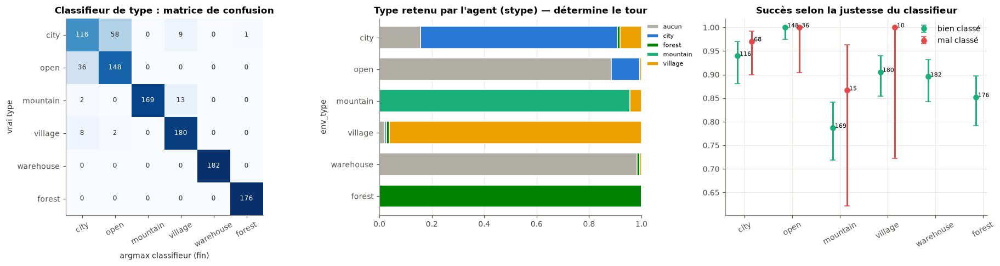

In [23]:
if "cls_argmax" in ep:
    cm = pd.crosstab(ep["env_type"], ep["cls_argmax"].map(lambda i: sd.TYPE_ORDER[int(i)] if i is not None and np.isfinite(i) and i >= 0 else "?"))
    cm = cm.reindex(index=TYPES, columns=[c for c in T + ["?"] if c in cm.columns], fill_value=0)
    cmn = cm.div(cm.sum(axis=1), axis=0)
    fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
    im = ax[0].imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    for i in range(cmn.shape[0]):
        for j in range(cmn.shape[1]):
            ax[0].text(j, i, f"{cm.iat[i, j]}", ha="center", va="center", fontsize=8, color="white" if cmn.iat[i, j] > 0.5 else "#2b2b29")
    ax[0].set_xticks(range(cm.shape[1]), cm.columns, rotation=30); ax[0].set_yticks(range(cm.shape[0]), cm.index)
    ax[0].set_xlabel("argmax classifieur (fin)"); ax[0].set_ylabel("vrai type"); ax[0].set_title("Classifieur de type : matrice de confusion"); ax[0].grid(False)
    # stype (route activée) vs vrai type
    st = pd.crosstab(ep["env_type"], ep["stype"].fillna("aucun")) if "stype" in ep else None
    if st is not None:
        st.div(st.sum(axis=1), axis=0).plot.barh(stacked=True, ax=ax[1], width=0.7, color=[TC.get(c, "#b0aea5") for c in st.columns], edgecolor="white")
        ax[1].invert_yaxis(); ax[1].set_title("Type retenu par l'agent (stype) — détermine le tour"); ax[1].legend(fontsize=7, bbox_to_anchor=(1, 1))
    # succès selon classification correcte
    ep["_cls_ok"] = ep["cls_argmax"].map(lambda i: sd.TYPE_ORDER[int(i)] if i is not None and np.isfinite(i) and i >= 0 else "?") == ep["env_type"].astype(str)
    rr = []
    for t in TYPES:
        for okc in (True, False):
            g = ep[(ep["env_type"] == t) & (ep["_cls_ok"] == okc)]
            if len(g):
                p, lo, hi = sd.wilson((~g["fail"]).sum(), len(g)); rr.append((t, okc, p, lo, hi, len(g)))
    rr = pd.DataFrame(rr, columns=["t", "ok", "p", "lo", "hi", "n"])
    for k, (okc, col) in enumerate([(True, SUCC_C), (False, FAIL_C)]):
        g = rr[rr["ok"] == okc]
        xi = np.array([TYPES.index(t) for t in g["t"]]) + (k - 0.5) * 0.3
        ax[2].errorbar(xi, g["p"], yerr=[g["p"] - g["lo"], g["hi"] - g["p"]], fmt="o", color=col, capsize=3, label="bien classé" if okc else "mal classé")
        for x_, p_, n_ in zip(xi, g["p"], g["n"]): ax[2].text(x_, p_, f" {n_}", fontsize=7)
    ax[2].set_xticks(range(len(TYPES)), TYPES, rotation=30); ax[2].legend(); ax[2].set_title("Succès selon la justesse du classifieur")
    fig.tight_layout(); save(fig, "08_classifier")

env_type,city,forest,mountain,open,village,warehouse
kind,,,,,,
esc,0,0,0,0,0,3
is_mountain,184,176,360,184,190,182
latched,419,388,380,377,403,367
rgb_latch,0,0,39,0,0,0
rgb_unlatch,0,0,9,0,0,0
tour_on,211,343,365,185,299,185


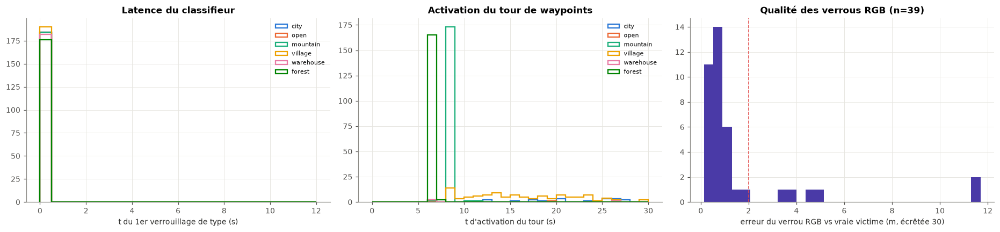

In [24]:
ev = sd.events_table(ep)
if len(ev):
    fig, ax = plt.subplots(1, 3, figsize=(17, 4))
    lat = ev[ev["kind"] == "latched"].groupby(["group", "seed"]).first().reset_index()
    for t in TYPES:
        v = lat.loc[lat["env_type"] == t, "t"]
        if len(v): ax[0].hist(v, bins=np.linspace(0, 12, 25), histtype="step", color=TC[t], label=t, lw=1.5)
    ax[0].set_xlabel("t du 1er verrouillage de type (s)"); ax[0].legend(fontsize=7); ax[0].set_title("Latence du classifieur")
    ton = ev[(ev["kind"] == "tour_on") & (ev["value"] == True)].groupby(["group", "seed"]).first().reset_index()
    for t in TYPES:
        v = ton.loc[ton["env_type"] == t, "t"]
        if len(v): ax[1].hist(v, bins=np.linspace(0, 30, 31), histtype="step", color=TC[t], label=t, lw=1.5)
    ax[1].set_xlabel("t d'activation du tour (s)"); ax[1].legend(fontsize=7); ax[1].set_title("Activation du tour de waypoints")
    rl = ev[ev["kind"] == "rgb_latch"]
    if len(rl) and "err_m" in rl:
        ax[2].hist(rl["err_m"].dropna().clip(upper=30), bins=30, color="#4a3aa7")
        ax[2].axvline(2, color=FAIL_C, ls="--", lw=1)
        ax[2].set_xlabel("erreur du verrou RGB vs vraie victime (m, écrêtée 30)"); ax[2].set_title(f"Qualité des verrous RGB (n={len(rl)})")
    fig.tight_layout(); save(fig, "08_events")
    display(ev.groupby(["kind", "env_type"], observed=True).size().unstack(fill_value=0))

,route_king,route_king+tour,route_king+rgb,route_av,esc_frac
env_type,,,,,
city,0.937,0.063,0.00,0.005,0.000
open,0.998,0.002,0.00,0.000,0.000
mountain,0.330,0.609,0.06,0.000,0.000
village,0.767,0.233,0.00,0.000,0.000
warehouse,0.993,0.007,0.00,0.000,0.016
forest,0.376,0.624,0.00,0.165,0.000


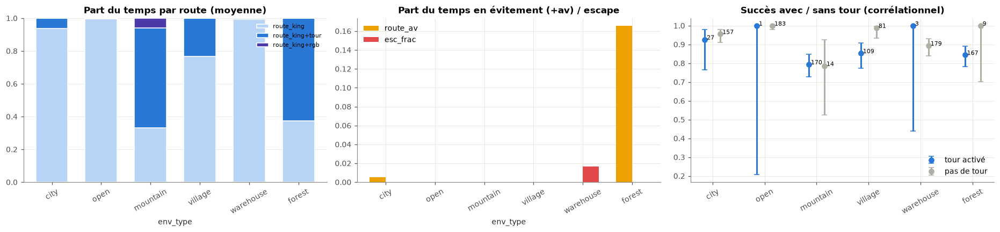

In [25]:
if HAS_TRAJ:
    rc = ["route_king", "route_king+tour", "route_king+rgb"]
    ru = epx.groupby("env_type", observed=True)[rc + ["route_av", "esc_frac"]].mean()
    fig, ax = plt.subplots(1, 3, figsize=(17, 4))
    ru[rc].plot.bar(stacked=True, ax=ax[0], color=["#b7d3f6", "#2a78d6", "#4a3aa7"], width=0.65, edgecolor="white")
    ax[0].set_title("Part du temps par route (moyenne)"); ax[0].tick_params(axis="x", rotation=30); ax[0].legend(fontsize=7)
    ru[["route_av", "esc_frac"]].plot.bar(ax=ax[1], color=["#eda100", "#e34948"], width=0.65)
    ax[1].set_title("Part du temps en évitement (+av) / escape"); ax[1].tick_params(axis="x", rotation=30)
    # succès selon usage du tour
    epx["_tour"] = epx["route_king+tour"] > 0
    rr = []
    for t in TYPES:
        for k in (True, False):
            g = epx[(epx["env_type"] == t) & (epx["_tour"] == k)]
            if len(g): p, lo, hi = sd.wilson((~g["fail"]).sum(), len(g)); rr.append((t, k, p, lo, hi, len(g)))
    rr = pd.DataFrame(rr, columns=["t", "k", "p", "lo", "hi", "n"])
    for j, (k, col) in enumerate([(True, "#2a78d6"), (False, "#b0aea5")]):
        g = rr[rr["k"] == k]; xi = np.array([TYPES.index(t) for t in g["t"]]) + (j - 0.5) * 0.3
        ax[2].errorbar(xi, g["p"], yerr=[g["p"] - g["lo"], g["hi"] - g["p"]], fmt="o", color=col, capsize=3, label="tour activé" if k else "pas de tour")
        for x_, p_, n_ in zip(xi, g["p"], g["n"]): ax[2].text(x_, p_, f" {n_}", fontsize=7)
    ax[2].set_xticks(range(len(TYPES)), TYPES, rotation=30); ax[2].legend(); ax[2].set_title("Succès avec / sans tour (corrélationnel)")
    fig.tight_layout(); save(fig, "08_routes")
    display(ru.round(3))

,rgb_used,rgb_n_req,rgb_n_fix,rgb_n_latch,rgb_n_dud
env_type,,,,,
city,1.34,0.00,0.00,0.00,0.00
open,1.01,0.00,0.00,0.00,0.00
mountain,24.44,23.73,1.93,0.21,0.05
village,1.56,0.00,0.00,0.00,0.00
warehouse,1.11,0.00,0.00,0.00,0.00
forest,1.52,0.00,0.00,0.00,0.00


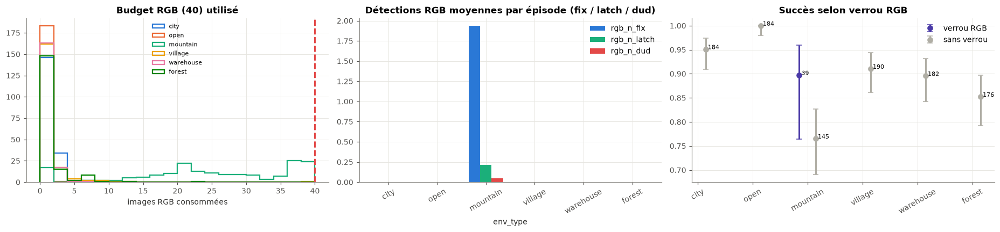

In [26]:
rgbc = [c for c in ["rgb_used", "rgb_n_req", "rgb_n_fix", "rgb_n_latch", "rgb_n_dud"] if c in ep]
if rgbc:
    fig, ax = plt.subplots(1, 3, figsize=(17, 4))
    for t in TYPES:
        v = ep.loc[ep["env_type"] == t, "rgb_used"].dropna()
        if len(v): ax[0].hist(v, bins=np.arange(0, 42, 2), histtype="step", color=TC[t], label=t, lw=1.5)
    ax[0].axvline(sd.RGB_BUDGET, color=FAIL_C, ls="--"); ax[0].set_xlabel("images RGB consommées"); ax[0].legend(fontsize=7)
    ax[0].set_title("Budget RGB (40) utilisé")
    agg = ep.groupby("env_type", observed=True)[rgbc].mean()
    agg.drop(columns=[c for c in ["rgb_used", "rgb_n_req"] if c in agg]).plot.bar(ax=ax[1], width=0.7, color=["#2a78d6", "#1baf7a", "#e34948"])
    ax[1].set_title("Détections RGB moyennes par épisode (fix / latch / dud)"); ax[1].tick_params(axis="x", rotation=30)
    if "rgb_n_latch" in ep:
        rr = []
        for t in TYPES:
            for k in (True, False):
                g = ep[(ep["env_type"] == t) & ((ep["rgb_n_latch"].fillna(0) > 0) == k)]
                if len(g): p, lo, hi = sd.wilson((~g["fail"]).sum(), len(g)); rr.append((t, k, p, lo, hi, len(g)))
        rr = pd.DataFrame(rr, columns=["t", "k", "p", "lo", "hi", "n"])
        for j, (k, col) in enumerate([(True, "#4a3aa7"), (False, "#b0aea5")]):
            g = rr[rr["k"] == k]; xi = np.array([TYPES.index(t) for t in g["t"]]) + (j - 0.5) * 0.3
            ax[2].errorbar(xi, g["p"], yerr=[g["p"] - g["lo"], g["hi"] - g["p"]], fmt="o", color=col, capsize=3, label="verrou RGB" if k else "sans verrou")
            for x_, p_, n_ in zip(xi, g["p"], g["n"]): ax[2].text(x_, p_, f" {n_}", fontsize=7)
        ax[2].set_xticks(range(len(TYPES)), TYPES, rotation=30); ax[2].legend(); ax[2].set_title("Succès selon verrou RGB")
    fig.tight_layout(); save(fig, "08_rgb")
    display(agg.round(2))

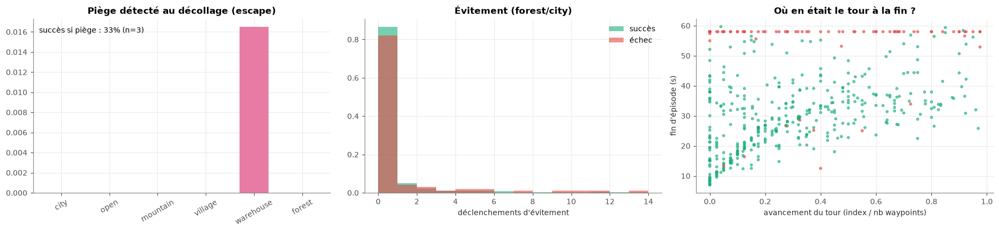

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
if "esc_trap" in ep:
    et = ep.groupby("env_type", observed=True)["esc_trap"].mean()
    ax[0].bar(et.index.astype(str), et.values, color=[TC[t] for t in et.index], width=0.6)
    ax[0].set_title("Piège détecté au décollage (escape)"); ax[0].tick_params(axis="x", rotation=30)
    tr_ = ep[ep["esc_trap"] == True]
    if len(tr_): ax[0].text(0.02, 0.92, f"succès si piège : {(~tr_['fail']).mean():.0%} (n={len(tr_)})", transform=ax[0].transAxes)
if "av_count" in ep:
    for ok, col, lab in [(True, SUCC_C, "succès"), (False, FAIL_C, "échec")]:
        ax[1].hist(ep.loc[(~ep["fail"]) == ok, "av_count"].dropna(), bins=np.arange(0, 15), alpha=0.6, color=col, label=lab, density=True)
    ax[1].set_xlabel("déclenchements d'évitement"); ax[1].legend(); ax[1].set_title("Évitement (forest/city)")
if "tour_waypoints" in ep:
    w = ep.dropna(subset=["tour_waypoints"])
    w = w[w["tour_waypoints"] > 0]
    if len(w):
        prog = w["tour_wp_index"] / w["tour_waypoints"]
        ax[2].scatter(prog, w["sim_time"], s=8, c=np.where(w["fail"], FAIL_C, SUCC_C), alpha=0.6)
        ax[2].set_xlabel("avancement du tour (index / nb waypoints)"); ax[2].set_ylabel("fin d'épisode (s)")
        ax[2].set_title("Où en était le tour à la fin ?")
fig.tight_layout(); save(fig, "08_escape_av_tour")

> **Lecture.**
> - **Classifieur.** Il confond city et open (58/184 seeds city classées open, 36 dans l'autre
>   sens). C'est sans effet : les seeds mal classées réussissent autant ou mieux (97 % et 100 %).
>   Mountain est reconnu à 92 % et warehouse et forest à 100 %.
> - **RGB.** Le détecteur n'est utilisé qu'en mountain (24 images sur 40 en moyenne) et ne
>   produit un verrou que dans **39/184 épisodes**. Avec verrou, le succès est de 90 %, contre
>   77 % sans (corrélationnel). Augmenter le taux de verrouillage est une piste pour mountain.
> - **Escape.** Il ne s'est déclenché que 3 fois (warehouse), sans détecter les pièges du
>   décollage (voir 16.2).

## 9. Cinématique

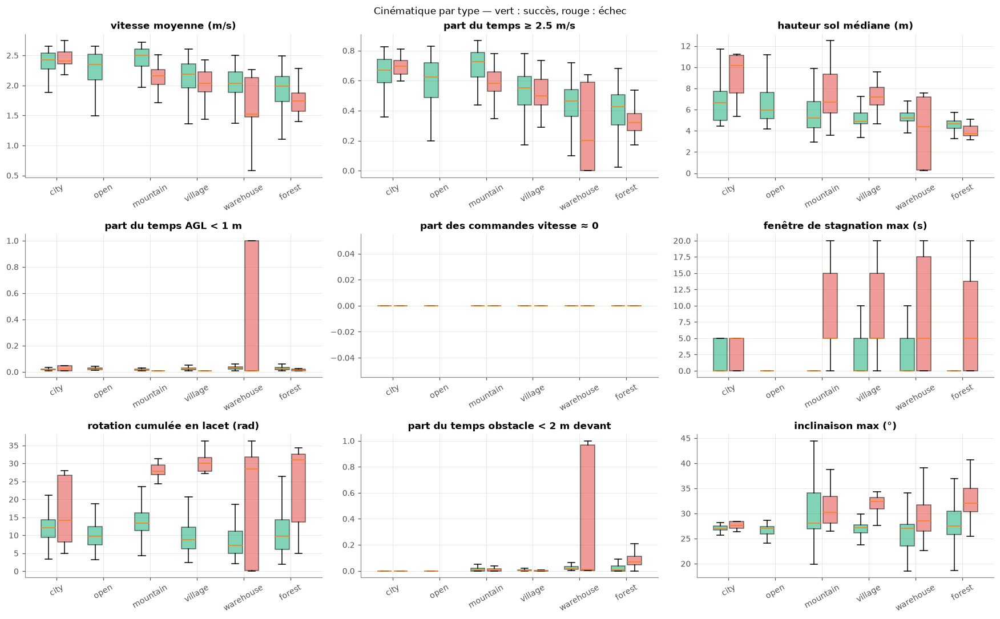

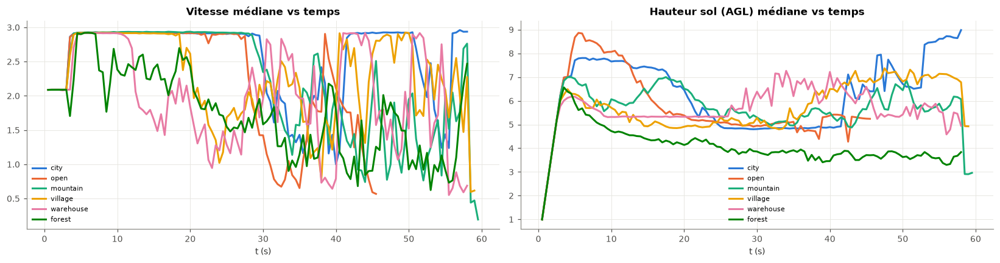

In [28]:
if HAS_TRAJ:
    kin = [("mean_speed", "vitesse moyenne (m/s)"), ("frac_fast", "part du temps ≥ 2.5 m/s"),
           ("agl_med", "hauteur sol médiane (m)"), ("frac_agl_lt1", "part du temps AGL < 1 m"),
           ("frac_cmd_zero", "part des commandes vitesse ≈ 0"), ("stuck_s", "fenêtre de stagnation max (s)"),
           ("yaw_travel_rad", "rotation cumulée en lacet (rad)"), ("frac_dmin_lt2", "part du temps obstacle < 2 m devant"),
           ("max_tilt_deg", "inclinaison max (°)")]
    kin = [k for k in kin if k[0] in epx]
    fig, axs = plt.subplots(3, 3, figsize=(16, 10))
    for a, (c, lab) in zip(axs.flat, kin):
        data, pos, cols = [], [], []
        for i, t in enumerate(TYPES):
            for j, ok in enumerate([True, False]):
                v = epx.loc[(epx["env_type"] == t) & ((~epx["fail"]) == ok), c].dropna()
                data.append(v if len(v) else [np.nan]); pos.append(i + (j - 0.5) * 0.35); cols.append(SUCC_C if ok else FAIL_C)
        bp = a.boxplot(data, positions=pos, widths=0.3, patch_artist=True, showfliers=False)
        for p, col in zip(bp["boxes"], cols): p.set_facecolor(col); p.set_alpha(0.55)
        a.set_xticks(range(len(TYPES)), TYPES, rotation=30); a.set_title(lab)
    fig.suptitle("Cinématique par type — vert : succès, rouge : échec")
    fig.tight_layout(); save(fig, "09_kinematics")

    fig, axs = plt.subplots(1, 2, figsize=(15, 4))
    for t in TYPES:
        m = (ep["env_type"] == t).to_numpy()
        axs[0].plot(grid, np.nanmedian(B["speed"].to_numpy()[m], 0), color=TC[t], label=t)
        axs[1].plot(grid, np.nanmedian(B["agl"].to_numpy()[m], 0), color=TC[t], label=t)
    axs[0].set_title("Vitesse médiane vs temps"); axs[1].set_title("Hauteur sol (AGL) médiane vs temps")
    for a in axs: a.set_xlabel("t (s)"); a.legend(fontsize=7)
    fig.tight_layout(); save(fig, "09_speed_agl_time")

## 10. Budget de calcul

Mesures en process (non calibrées) : `HW_FACTOR` convertit en secondes baseline-équivalentes. Au-delà
de 0.6 s/pas (2 s au premier pas), le runner Docker compte un *strike* ; 15 strikes font échouer la seed.

env_type               city     open  mountain  village  warehouse   forest
act_ms_mean  count    184.0    184.0     184.0    190.0      182.0    176.0
             mean      92.2     99.3      93.1     87.5       94.9     97.8
             std       21.7     24.2      21.4     21.8       22.6     20.7
             min       41.3     41.7      39.3     34.5       43.1     43.2
             25%       92.5    100.3      95.0     87.4       94.5     97.3
             50%       98.6    107.0     100.6     95.3      101.5    103.0
             75%      104.7    112.3     105.6     99.7      106.3    109.3
             max      134.1    130.9     120.6    129.2      156.0    136.8
act_ms_p95   count    184.0    184.0     184.0    190.0      182.0    176.0
             mean     242.8    269.4     246.3    225.1      248.2    260.8
             std       86.3     97.0      85.4     86.2       87.9     83.4
             min       51.8     51.7      50.6     45.9       53.0     51.1
             25%      239.5    270.0     251.9    225.8      241.4    252.6
             50%      264.6    299.8     273.5    254.1      275.2    281.2
             75%      289.0    320.9     293.1    274.2      294.4    305.0
             max      451.8    433.0     379.2    386.1      415.0    459.5
act_ms_max   count    184.0    184.0     184.0    190.0      182.0    176.0
             mean    1185.3   1237.0    1234.5   1030.6     1035.2   1223.4
             std     1140.8   1130.3    1130.3    575.2      528.4   1137.0
             min       62.6     62.8      66.9     57.3       60.1     65.6
             25%      870.3   1002.9     959.0    805.0      844.3    914.5
             50%     1172.3   1204.0    1240.6   1079.4     1086.2   1189.1
             75%     1463.2   1523.7    1501.3   1414.8     1336.4   1469.1
             max    14416.3  14383.3   14447.0   3197.6     2688.0  14383.6
act_ms_first count    184.0    184.0     184.0    190.0      182.0    176.0
             mean     101.4    100.3     129.9    103.7      103.5     90.1
             std       88.3     83.9     104.6    131.7       94.8     79.4
             min       41.6     35.8      47.0     38.0       38.6     40.3
             25%       56.7     55.3      71.1     53.7       55.0     52.5
             50%       73.8     69.5      88.1     66.1       72.8     67.6
             75%      109.2    101.3     136.6     97.6      103.0     90.3
             max      664.4    622.6     615.5   1338.6      825.8    585.7
wall_sec     count    184.0    184.0     184.0    190.0      182.0    176.0
             mean     161.1    158.5     462.8    147.3      252.3    243.1
             std       61.9     61.7     206.6     89.6      179.9    151.7
             min       44.7     30.4      96.5     22.4        5.7     30.3
             25%      108.3    109.6     319.3     83.3      140.1    124.8
             50%      162.8    165.1     450.5    119.5      213.6    219.8
             75%      198.0    201.4     626.5    184.3      297.2    318.3
             max      349.4    316.6     873.4    391.3      841.6    670.6

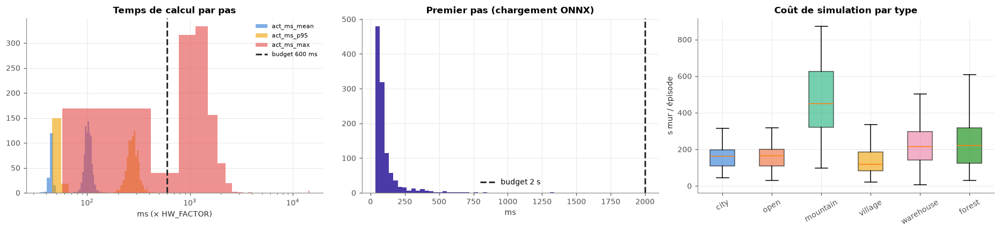

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
for c, col in [("act_ms_mean", "#2a78d6"), ("act_ms_p95", "#eda100"), ("act_ms_max", "#e34948")]:
    if c in ep: ax[0].hist(ep[c] * HW_FACTOR, bins=40, alpha=0.6, color=col, label=c)
ax[0].axvline(sd.ACT_BUDGET_MS, color="#2b2b29", ls="--", label="budget 600 ms"); ax[0].set_xscale("log")
ax[0].legend(fontsize=7); ax[0].set_xlabel("ms (× HW_FACTOR)"); ax[0].set_title("Temps de calcul par pas")
if "act_ms_first" in ep:
    ax[1].hist(ep["act_ms_first"] * HW_FACTOR, bins=40, color="#4a3aa7")
    ax[1].axvline(sd.FIRST_STEP_BUDGET_MS, color="#2b2b29", ls="--", label="budget 2 s"); ax[1].legend()
    ax[1].set_title("Premier pas (chargement ONNX)"); ax[1].set_xlabel("ms")
if "wall_sec" in ep:
    d = [ep.loc[ep["env_type"] == t, "wall_sec"] for t in TYPES]
    bp = ax[2].boxplot(d, tick_labels=TYPES, patch_artist=True, showfliers=False)
    for p, t in zip(bp["boxes"], TYPES): p.set_facecolor(TC[t]); p.set_alpha(0.6)
    ax[2].set_ylabel("s mur / épisode"); ax[2].set_title("Coût de simulation par type"); ax[2].tick_params(axis="x", rotation=30)
fig.tight_layout(); save(fig, "10_compute")
ep.groupby("env_type", observed=True)[[c for c in ["act_ms_mean", "act_ms_p95", "act_ms_max", "act_ms_first", "wall_sec"] if c in ep]].describe().T.round(1)

> **Lecture.** En Docker, aucune seed n'échoue pour cause de calcul (100 % d'exécutions propres).
> En process, on mesure environ 95 ms par pas en moyenne et 250 ms au p95. Les pics maximaux
> au-delà de 1 s viennent de la contention à 6 workers sur le VPS ; ils ne se retrouvent pas dans
> les strikes du benchmark. La simulation coûte cher en mountain : 177 s de mur par seed en Docker,
> soit 4.6 fois le temps simulé.

## 11. Galerie de trajectoires

Vue du dessus (carte de hauteur, cercle de recherche, victime, trajet coloré par le temps) + séries
temporelles. `plot_episode(group, seed)` pour inspecter n'importe quelle seed.

20 épisodes dans la galerie


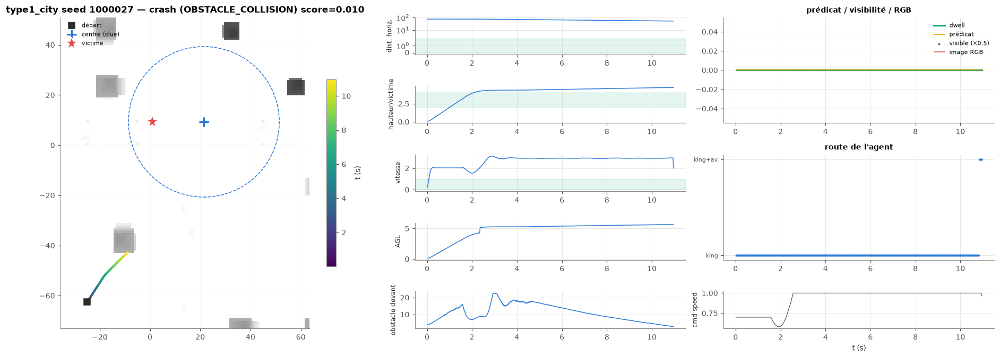

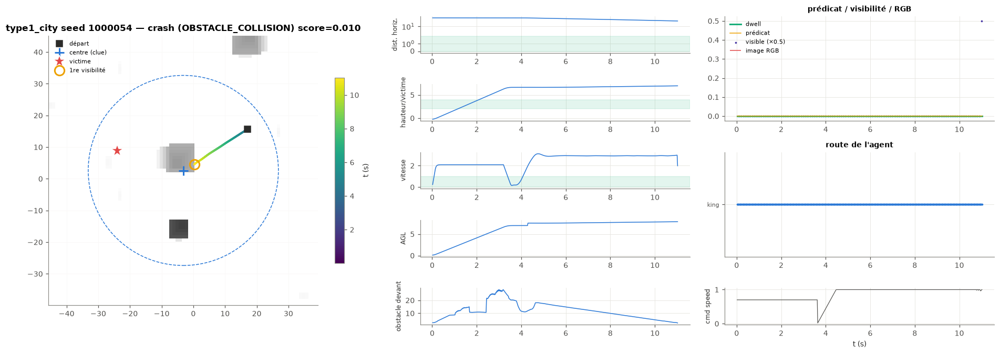

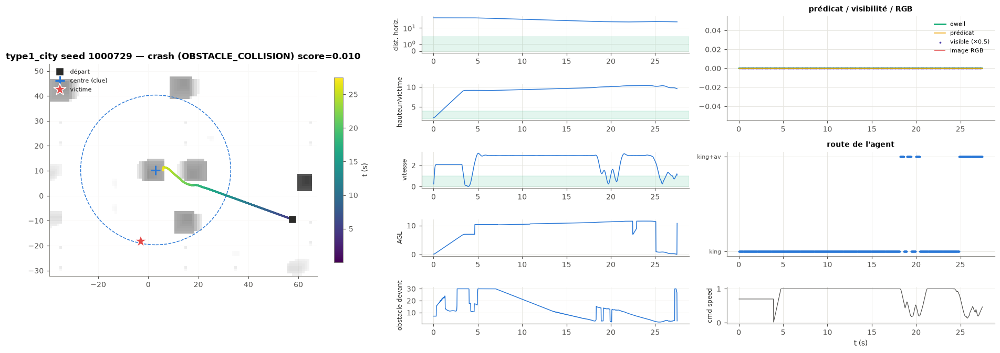

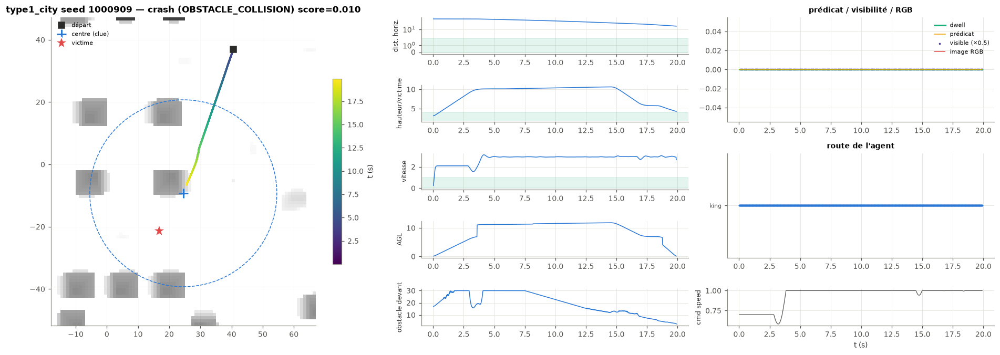

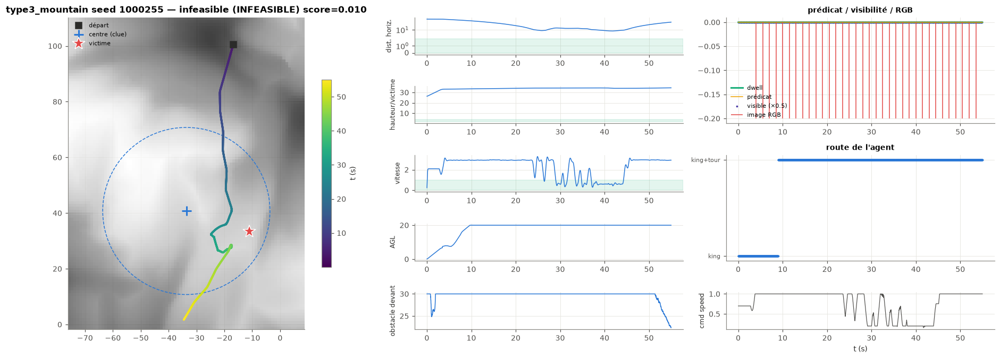

...

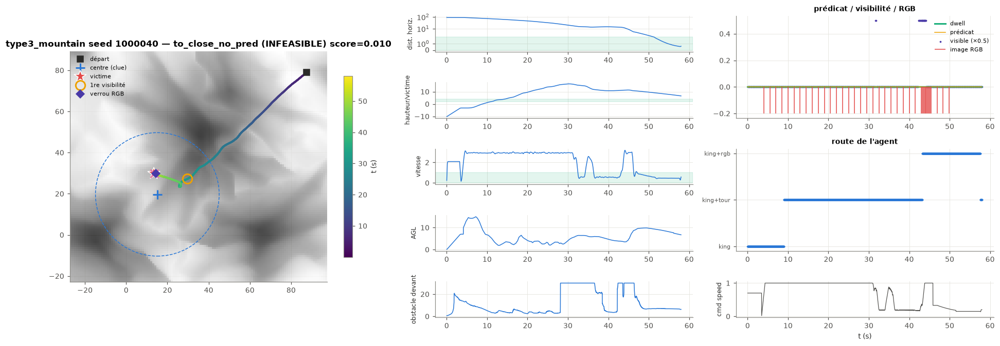

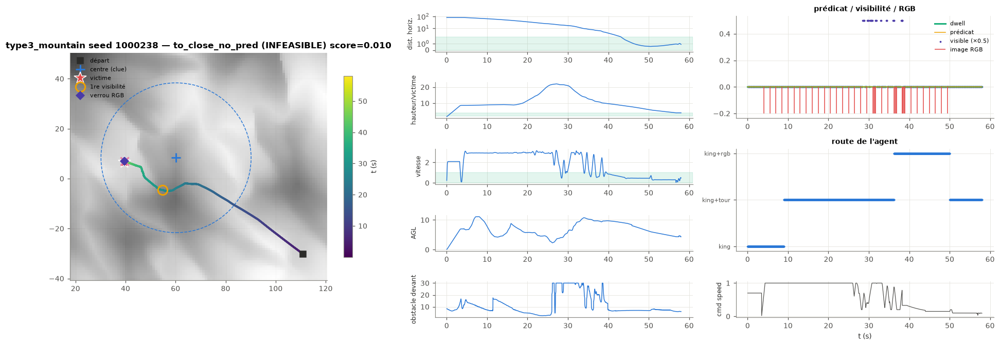

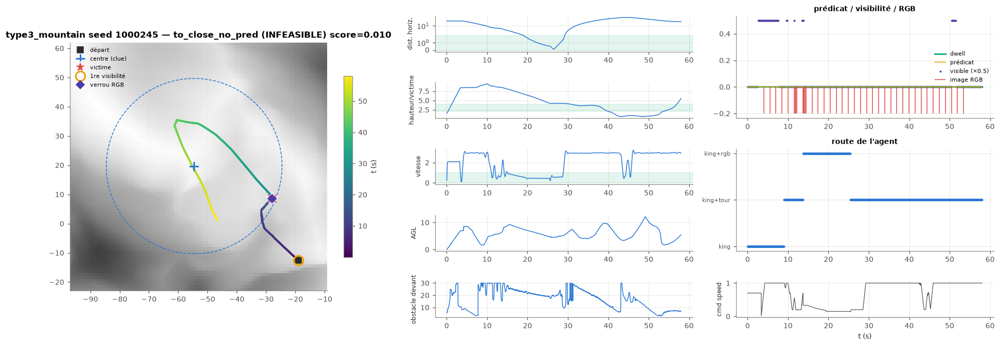

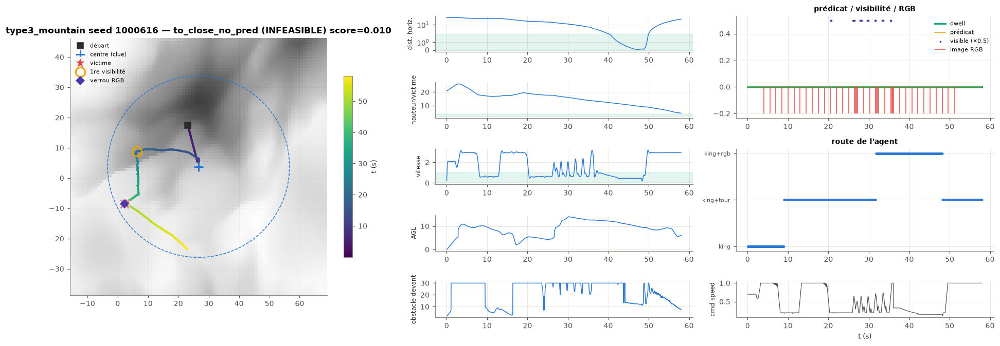

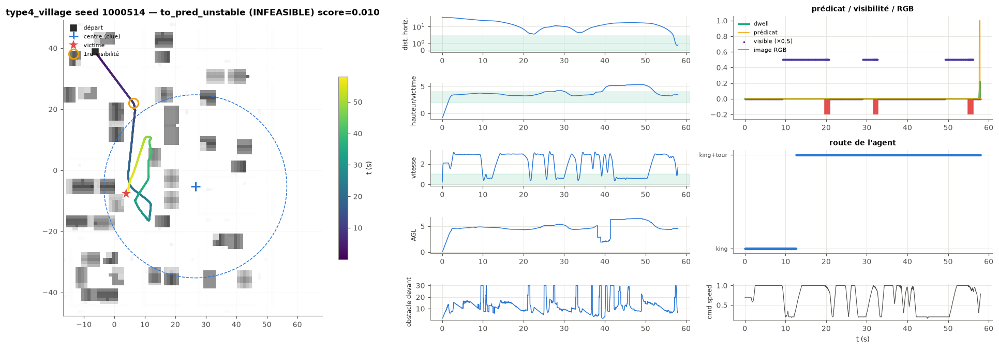

In [30]:
def plot_episode(group, seed, run=RUN_A, df=ep):
    r = df[(df["group"] == group) & (df["seed"] == int(seed))].iloc[0]
    tr = sd.load_traj(run, group, seed)
    if tr is None:
        print("pas de trajectoire"); return
    fig = plt.figure(figsize=(17, 6.2))
    gs = fig.add_gridspec(5, 3, width_ratios=[1.25, 1, 1])
    a = fig.add_subplot(gs[:, 0])
    if "hm_z" in tr:
        a.pcolormesh(tr["hm_x"], tr["hm_y"], tr["hm_z"], cmap="Greys", shading="auto", alpha=0.75)
    a.add_patch(Circle((r["centre_x"], r["centre_y"]), 30, fill=False, ls="--", color="#2a78d6"))
    sc_ = a.scatter(tr["x"], tr["y"], c=tr["t"], cmap="viridis", s=2)
    a.plot(r["start_x"], r["start_y"], "s", color="#2b2b29", ms=8, label="départ")
    a.plot(r["centre_x"], r["centre_y"], "+", color="#2a78d6", ms=12, mew=2, label="centre (clue)")
    a.plot(r["victim_x"], r["victim_y"], "*", color=FAIL_C, ms=16, mec="white", label="victime")
    v1 = np.flatnonzero(tr["vis"] == 1)
    if v1.size: a.plot(tr["x"][v1[0]], tr["y"][v1[0]], "o", mfc="none", mec="#eda100", ms=12, mew=2, label="1re visibilité")
    for b in (r.get("rgb_bad_spots") or []): a.plot(b[0], b[1], "x", color="#e87ba4", ms=10, mew=2)
    for e in (r.get("events") or []):
        if e["kind"] == "rgb_latch": a.plot(e["value"][0], e["value"][1], "D", color="#4a3aa7", ms=7, label="verrou RGB")
    a.set_aspect("equal"); a.legend(fontsize=7, loc="upper left"); fig.colorbar(sc_, ax=a, label="t (s)", shrink=0.6)
    a.set_title(f"{group} seed {seed} — {r['outcome']} ({r['failure_reason']}) score={r['score']:.3f}")
    t = tr["t"]
    spec = [("hdist", "dist. horiz.", (0, 2)), ("h_above", "hauteur/victime", (2, 4)), ("speed", "vitesse", (0, 1)),
            ("agl", "AGL", None), ("depth_min_c", "obstacle devant", None)]
    for k, (c, lab, band) in enumerate(spec):
        ax_ = fig.add_subplot(gs[k, 1]); ax_.plot(t, tr[c], lw=1, color="#2a78d6")
        if band: ax_.axhspan(*band, color="#1baf7a", alpha=0.12)
        ax_.set_ylabel(lab, fontsize=8)
        if c == "hdist": ax_.set_yscale("symlog", linthresh=2)
    codes = sd.decode_codes(r.get("route_codes")); ecodes = sd.decode_codes(r.get("esc_codes"))
    ax_ = fig.add_subplot(gs[0:2, 2]); ax_.plot(t, tr["dwell"], color="#1baf7a", label="dwell"); ax_.plot(t, tr["pred"], color="#eda100", lw=1, label="prédicat")
    vv = tr["vis"] >= 0; ax_.scatter(t[vv], tr["vis"][vv] * 0.5, s=2, color="#4a3aa7", label="visible (×0.5)")
    rs = np.flatnonzero(tr["rgb_served"] == 1); ax_.vlines(t[rs], -0.2, 0, color=FAIL_C, lw=1, label="image RGB")
    ax_.legend(fontsize=7); ax_.set_title("prédicat / visibilité / RGB", fontsize=9)
    ax_ = fig.add_subplot(gs[2:4, 2])
    labs = np.array([codes.get(int(c), "none") for c in tr["route"]])
    uniq = list(dict.fromkeys(labs))
    ax_.scatter(t, [uniq.index(l) for l in labs], s=2, color="#2a78d6")
    el = np.array([ecodes.get(int(c), "none") for c in tr["esc"]])
    esc_on = np.isin(el, ["scan", "creep", "climb"])
    if esc_on.any(): ax_.scatter(t[esc_on], np.full(esc_on.sum(), -1), s=2, color=FAIL_C); uniq_l = ["escape"] + uniq
    else: uniq_l = uniq
    ax_.set_yticks(range(-1 if esc_on.any() else 0, len(uniq)), uniq_l, fontsize=7); ax_.set_title("route de l'agent", fontsize=9)
    ax_ = fig.add_subplot(gs[4, 2]); ax_.plot(t, tr["a_speed"], lw=0.8, color="#52514e"); ax_.set_ylabel("cmd speed", fontsize=8); ax_.set_xlabel("t (s)")
    fig.tight_layout()
    return fig

gal = ep[ep["fail"]].sort_values(["outcome", "env_type", "seed"]).groupby("outcome", observed=True).head(N_GALLERY)
print(f"{len(gal)} épisodes dans la galerie")
for _, r in gal.iterrows():
    f = plot_episode(r["group"], r["seed"])
    if f is not None: save(f, f"11_ep_{r['group']}_{r['seed']}"); plt.show(); plt.close(f)

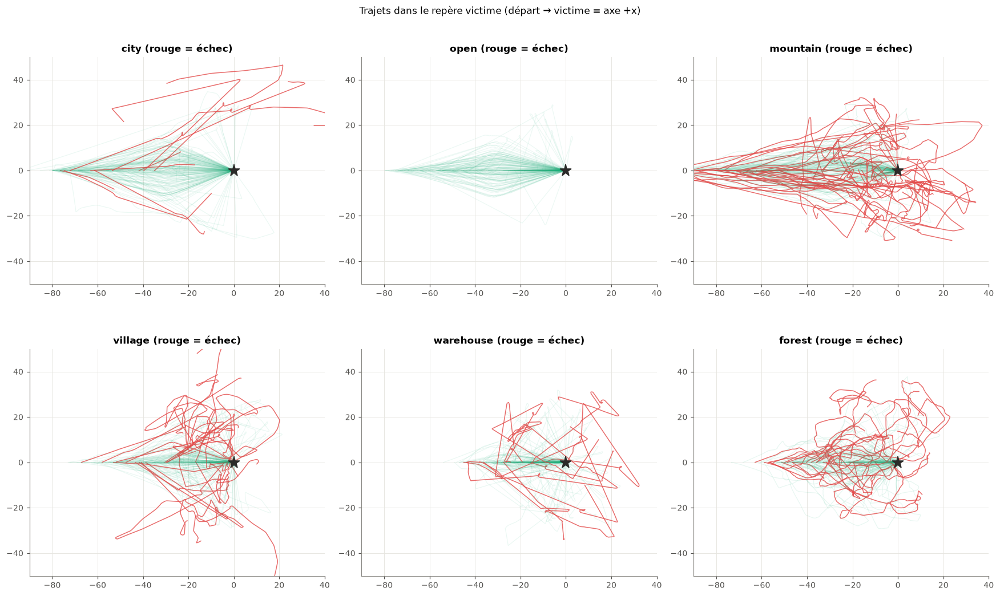

In [31]:
# Superposition des trajets dans le repère de la victime (victime en 0, départ vers la gauche)
if HAS_TRAJ:
    fig, axs = plt.subplots(2, 3, figsize=(16, 10))
    for a, t in zip(axs.flat, T):
        g = ep[ep["env_type"] == t]
        a_ok = float(np.clip(15 / max(1, (~g["fail"]).sum()), 0.08, 0.8))
        for _, r in g.iterrows():
            tr = sd.load_traj(RUN_A, r["group"], r["seed"])
            if tr is None: continue
            ang = np.arctan2(r["victim_y"] - r["start_y"], r["victim_x"] - r["start_x"])
            ca, sa = np.cos(-ang), np.sin(-ang)
            dx, dy = tr["x"] - r["victim_x"], tr["y"] - r["victim_y"]
            px, py = ca * dx - sa * dy, sa * dx + ca * dy
            a.plot(px[::10], py[::10], color=FAIL_C if r["fail"] else SUCC_C, alpha=0.8 if r["fail"] else a_ok, lw=1 if r["fail"] else 0.8)
        a.plot(0, 0, "*", color="#2b2b29", ms=14); a.set_aspect("equal"); a.set_xlim(-90, 40); a.set_ylim(-50, 50)
        a.set_title(f"{t} (rouge = échec)")
    fig.suptitle("Trajets dans le repère victime (départ → victime = axe +x)")
    fig.tight_layout(); save(fig, "11_overlay")

## 12. Cohérence avec le benchmark Docker (optionnel)

1100 seeds communes ; score en process 0.8900 vs benchmark 0.8917
désaccords succès/échec : 6 (0.5%)


,group,seed,env_type,score_proc,success_proc,score_bench,success_bench
20,type1_city,1000027,city,0.01,False,1.000,True
43,type1_city,1000054,city,0.01,False,0.988,True
404,type1_city,1000309,city,0.90,True,0.010,False
445,type1_city,1000369,city,1.00,True,0.010,False
790,type1_city,1000729,city,0.01,False,0.900,True
938,type1_city,1000909,city,0.01,False,0.966,True


execution_status
seed_done    1100
Name: count, dtype: int64

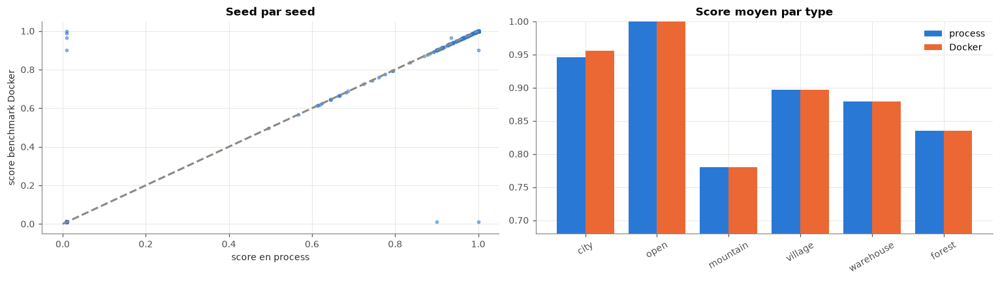

In [32]:
if BENCH_A is not None and Path(BENCH_A).exists():
    bm = sd.load_benchmark(BENCH_A)
    j = ep[["group", "seed", "env_type", "score", "success"]].merge(bm[["group", "seed", "score", "success"]], on=["group", "seed"], suffixes=("_proc", "_bench"))
    print(f"{len(j)} seeds communes ; score en process {j['score_proc'].mean():.4f} vs benchmark {j['score_bench'].mean():.4f}")
    dis = j[j["success_proc"] != j["success_bench"]]
    print(f"désaccords succès/échec : {len(dis)} ({len(dis) / max(1, len(j)):.1%})")
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    ax[0].scatter(j["score_proc"], j["score_bench"], s=8, alpha=0.5, color="#2a78d6"); ax[0].plot([0, 1], [0, 1], color="#8a8984", ls="--")
    ax[0].set_xlabel("score en process"); ax[0].set_ylabel("score benchmark Docker"); ax[0].set_title("Seed par seed")
    g = j.groupby("env_type", observed=True)[["score_proc", "score_bench"]].mean()
    xx = np.arange(len(g)); ax[1].bar(xx - 0.2, g["score_proc"], 0.4, color="#2a78d6", label="process"); ax[1].bar(xx + 0.2, g["score_bench"], 0.4, color="#eb6834", label="Docker")
    ax[1].set_xticks(xx, g.index.astype(str), rotation=30); ax[1].set_ylim(max(0, g.min().min() - 0.1), 1); ax[1].legend(); ax[1].set_title("Score moyen par type")
    fig.tight_layout(); save(fig, "12_bench_consistency")
    display(dis.head(30))
    if "execution_status" in bm: display(bm["execution_status"].value_counts())
else:
    print("Pas de JSON de benchmark : section ignorée.")

> **Lecture.** Le process et Docker concordent : 0.8900 contre 0.8917 et 6 désaccords sur 1 100.
> Les 6 sont en **city** : 4 crashs en process réussissent en Docker, et 2 succès en process
> échouent en Docker. Tous les autres types sont identiques seed par seed. City est donc
> légèrement non déterministe (timing ou évitement), et les rollouts en process sont un proxy
> fiable pour itérer.

## 13. A/B apparié : champion vs variante

Mêmes seeds des deux côtés → test apparié. Score : IC bootstrap de la différence moyenne et test
de permutation (sign-flip). Succès : test exact de McNemar sur les paires discordantes.

In [33]:
if RUN_B is not None and Path(RUN_B, "episodes.jsonl").exists():
    epB = sd.load_episodes(RUN_B); epB = epB[epB["ok"]]
    m = sd.paired(ep, epB)
    print(f"{len(m)} seeds appariées — {LABEL_A} {m['score_a'].mean():.4f} vs {LABEL_B} {m['score_b'].mean():.4f}")
    ab = sd.ab_summary(m)
    display(ab.round(4))
    fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
    y = np.arange(len(ab))
    ax[0].errorbar(ab["delta"], y, xerr=[ab["delta"] - ab["ci_lo"], ab["ci_hi"] - ab["delta"]], fmt="o", color="#2a78d6", capsize=3)
    ax[0].axvline(0, color="#8a8984", ls="--"); ax[0].set_yticks(y, [f"{i} (n={n})" for i, n in zip(ab.index, ab["n"])]); ax[0].invert_yaxis()
    ax[0].set_xlabel(f"Δ score ({LABEL_B} − {LABEL_A})"); ax[0].set_title("Différence appariée (IC 95 %)")
    tm = pd.crosstab(m["outcome_a"], m["outcome_b"])
    tm = tm.loc[tm.sum(axis=1) > 0, tm.sum(axis=0) > 0]
    ax[1].imshow(np.log1p(tm), cmap="Blues"); ax[1].grid(False)
    for i in range(tm.shape[0]):
        for jj in range(tm.shape[1]): ax[1].text(jj, i, tm.iat[i, jj], ha="center", va="center", fontsize=8)
    ax[1].set_xticks(range(tm.shape[1]), tm.columns, rotation=40, ha="right", fontsize=7); ax[1].set_yticks(range(tm.shape[0]), tm.index, fontsize=7)
    ax[1].set_xlabel(LABEL_B); ax[1].set_ylabel(LABEL_A); ax[1].set_title("Transitions d'issue par seed")
    dd = m.loc[m["d_score"].abs() > 1e-6, "d_score"]
    ax[2].hist(dd, bins=40, color="#eb6834"); ax[2].set_xlabel("Δ score par seed (seeds changées seulement)")
    ax[2].set_title(f"{(m['d_score'].abs() > 1e-6).sum()} seeds changées / {len(m)}")
    fig.tight_layout(); save(fig, "13_ab")
    flips = m[m["success_a"] != m["success_b"]].sort_values(["env_type", "seed"])
    display(flips[["group", "seed", "outcome_a", "outcome_b", "score_a", "score_b"]])
else:
    print("RUN_B absent : section ignorée.")

RUN_B absent : section ignorée.


## 14. Puissance statistique

Quelle amélioration peut-on détecter ? Pour un A/B apparié, seul compte le nombre de seeds dont
l'issue change. Pour une comparaison non appariée (ex. score public vs set caché), l'écart-type par
seed (~0.25) domine.

Gain net de seeds réussies nécessaire pour +0.005 de score sur 1 100 seeds : 5.9


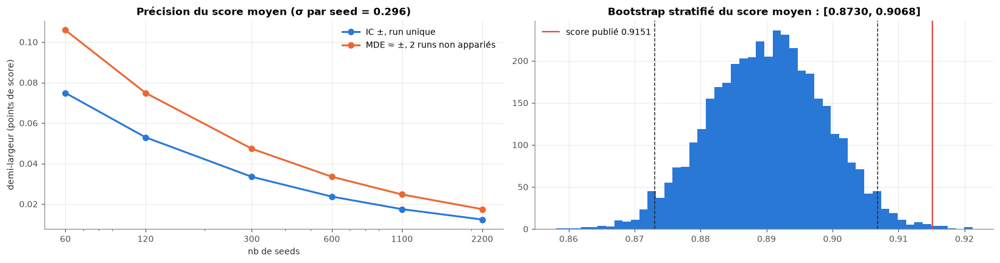

In [34]:
sdv = ep["score"].std()
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ns = np.array([60, 120, 300, 600, 1100, 2200])
ax[0].plot(ns, 1.96 * sdv / np.sqrt(ns), marker="o", color="#2a78d6", label="IC ±, run unique")
ax[0].plot(ns, 1.96 * sdv * np.sqrt(2) / np.sqrt(ns), marker="o", color="#eb6834", label="MDE ≈ ±, 2 runs non appariés")
ax[0].set_xscale("log"); ax[0].set_xticks(ns, ns); ax[0].set_xlabel("nb de seeds"); ax[0].set_ylabel("demi-largeur (points de score)")
ax[0].legend(); ax[0].set_title(f"Précision du score moyen (σ par seed = {sdv:.3f})")
boot = sd.stratified_bootstrap_mean(ep, "score")
ax[1].hist(boot, bins=50, color="#2a78d6")
lo, hi = np.quantile(boot, [0.025, 0.975])
for v in (lo, hi): ax[1].axvline(v, color="#2b2b29", ls="--", lw=1)
ax[1].axvline(0.9151, color=FAIL_C, lw=1.5, label="score publié 0.9151"); ax[1].legend()
ax[1].set_title(f"Bootstrap stratifié du score moyen : [{lo:.4f}, {hi:.4f}]")
fig.tight_layout(); save(fig, "14_power")
# Paires discordantes nécessaires : pour Δ score = k × 0.94 / N, il faut k seeds nettes gagnées.
print("Gain net de seeds réussies nécessaire pour +0.005 de score sur 1 100 seeds :", round(0.005 * 1100 / 0.94, 1))

## 15. Synthèse : où chercher le gain ?

Pour chaque classe d'échec : effectif, part de la perte totale, et **gain maximal** si ces seeds
étaient réussies avec le score moyen des succès de leur type. Pour le temps : gain si tous les
succès confirmaient dans le temps cible. C'est une borne supérieure, pas une prévision.

,poste,n,types,perte_pts,gain_max
0,temps écoulé : vue mais jamais < 2 m,44,"mountain:15, forest:13, warehouse:9, village:7",3.960e-02,3.880e-02
1,temps écoulé : victime jamais visible,29,"mountain:17, village:5, city:4, warehouse:2, f...",2.610e-02,2.560e-02
2,crash (collision/tilt),22,"forest:9, warehouse:7, city:5, village:1",1.980e-02,1.950e-02
3,temps écoulé : < 2 m sans prédicat,10,"mountain:5, village:2, forest:2, warehouse:1",9.000e-03,8.800e-03
4,terme temps (succès lents),32,,6.500e-03,6.500e-03
5,terme sécurité,144,,5.500e-03,5.500e-03
6,infaisable tôt (loin du cercle),3,"mountain:1, village:1, forest:1",2.700e-03,2.600e-03
7,temps écoulé : prédicat instable,1,village:1,9.000e-04,9.000e-04


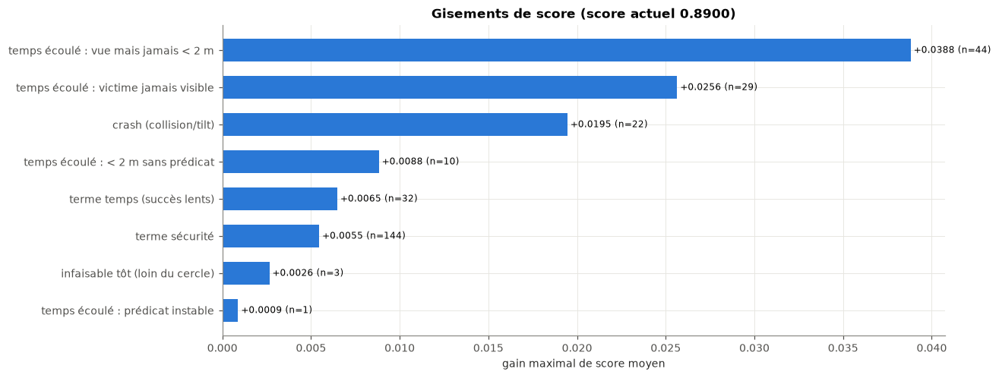

In [35]:
succ_mean_by_type = ep[~ep["fail"]].groupby("env_type", observed=True)["score"].mean()
rows = []
for o, g in ep[ep["fail"]].groupby("outcome", observed=True):
    gain = sum(succ_mean_by_type.get(t, 0.95) - s for t, s in zip(g["env_type"], g["score"])) / len(ep)
    rows.append(dict(poste=OL[o], n=len(g), types=", ".join(f"{k}:{v}" for k, v in g["env_type"].value_counts().items() if v),
                     perte_pts=g["loss_total"].sum() / len(ep), gain_max=gain))
rows.append(dict(poste="terme temps (succès lents)", n=int((ep["loss_time"] > 0).sum()), types="",
                 perte_pts=ep["loss_time"].sum() / len(ep), gain_max=ep["loss_time"].sum() / len(ep)))
rows.append(dict(poste="terme sécurité", n=int((ep["loss_safety"] > 0).sum()), types="",
                 perte_pts=ep["loss_safety"].sum() / len(ep), gain_max=ep["loss_safety"].sum() / len(ep)))
prio = pd.DataFrame(rows).sort_values("gain_max", ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(12, 0.45 * len(prio) + 1))
ax.barh(prio["poste"], prio["gain_max"], color="#2a78d6", height=0.6); ax.invert_yaxis()
for i, (v, n) in enumerate(zip(prio["gain_max"], prio["n"])): ax.text(v, i, f" +{v:.4f} (n={n})", va="center", fontsize=8)
ax.set_xlabel("gain maximal de score moyen"); ax.set_title(f"Gisements de score (score actuel {ep['score'].mean():.4f})")
fig.tight_layout(); save(fig, "15_priorities")
prio.round(4)

## 16. Analyses complémentaires (run complet)

Zooms sur les signaux trouvés dans le run 1 100 seeds : posture de la victime, crashs au décollage
en warehouse, visibilité sans détection, coût du benchmark officiel et cascade des gains.

### 16.1 Victimes allongées

victim_lying,False,True
env_type,,
city,0.951,NaN
open,1.000,1.000
mountain,0.850,0.614
village,0.913,0.857
warehouse,0.896,NaN
forest,0.873,0.545


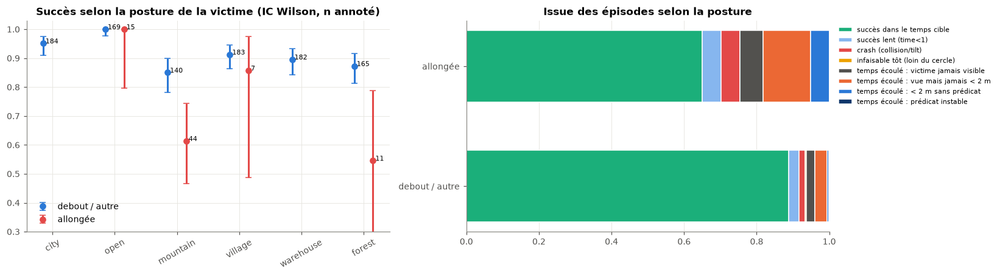

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.2))
rr = []
for t in TYPES:
    for ly in (False, True):
        g = ep[(ep["env_type"] == t) & (ep["victim_lying"] == ly)]
        if len(g): p, lo, hi = sd.wilson((~g["fail"]).sum(), len(g)); rr.append((t, ly, p, lo, hi, len(g)))
rr = pd.DataFrame(rr, columns=["t", "ly", "p", "lo", "hi", "n"])
for j, (ly, col, lab) in enumerate([(False, "#2a78d6", "debout / autre"), (True, "#e34948", "allongée")]):
    g = rr[rr["ly"] == ly]; xi = np.array([TYPES.index(t) for t in g["t"]]) + (j - 0.5) * 0.3
    ax[0].errorbar(xi, g["p"], yerr=[g["p"] - g["lo"], g["hi"] - g["p"]], fmt="o", color=col, capsize=3, label=lab)
    for x_, p_, n_ in zip(xi, g["p"], g["n"]): ax[0].text(x_, p_, f" {n_}", fontsize=7)
ax[0].set_xticks(range(len(TYPES)), TYPES, rotation=30); ax[0].legend(); ax[0].set_ylim(0.3, 1.03)
ax[0].set_title("Succès selon la posture de la victime (IC Wilson, n annoté)")
ct = pd.crosstab(ep["victim_lying"], ep["outcome"], normalize="index").reindex(columns=sd.OUTCOME_ORDER, fill_value=0)
ct = ct.loc[:, ct.sum() > 0]
left = np.zeros(len(ct))
for o in ct.columns:
    ax[1].barh(["debout / autre", "allongée"], ct[o], left=left, color=OC[o], label=OL[o], height=0.6, edgecolor="white")
    left += ct[o].to_numpy()
ax[1].set_xlim(0, 1); ax[1].legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
ax[1].set_title("Issue des épisodes selon la posture")
fig.tight_layout(); save(fig, "16_lying")
pd.crosstab(ep["env_type"], ep["victim_lying"], values=~ep["fail"], aggfunc="mean").round(3)

> **Lecture.** Les victimes allongées représentent 7 % des seeds mais 21 % des échecs (23/109). Elles
> se concentrent en mountain (44) et forest (11). L'échec typique est « vue mais jamais approchée » :
> la silhouette au sol est petite et peu contrastée. Un apprentissage ou un seuil de détection dédié
> à ce cas vaut au plus +0.016.

### 16.2 Warehouse : crashs au décollage

,seed,sim_time,d_start_centre,esc_trap,score
71,1000059,0.32,51.747,False,0.01
209,1000193,0.32,14.987,True,0.01
407,1000397,0.32,54.429,False,0.01
455,1000448,0.36,11.198,True,0.01
887,1000875,0.36,52.916,False,0.01
905,1000900,0.32,25.656,False,0.01
947,1000950,0.32,35.664,False,0.01


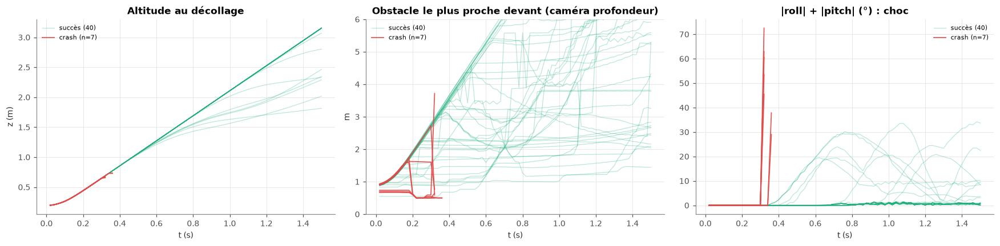

In [37]:
wc = epx[(epx["env_type"] == "warehouse") & (epx["outcome"] == "crash")]
wok = epx[(epx["env_type"] == "warehouse") & ~epx["fail"]].head(40)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for g, col, lab in [(wok, SUCC_C, "succès (40)"), (wc, FAIL_C, f"crash (n={len(wc)})")]:
    first = True
    for _, r in g.iterrows():
        tr = sd.load_traj(RUN_A, r["group"], r["seed"])
        if tr is None: continue
        m = tr["t"] <= 1.5
        kw = dict(color=col, alpha=0.9 if col == FAIL_C else 0.3, lw=1.2 if col == FAIL_C else 0.8, label=lab if first else None)
        ax[0].plot(tr["t"][m], tr["z"][m], **kw); ax[1].plot(tr["t"][m], tr["depth_min_c"][m], **kw)
        ax[2].plot(tr["t"][m], np.degrees(np.abs(tr["pitch"][m]) + np.abs(tr["roll"][m])), **kw)
        first = False
ax[0].set_title("Altitude au décollage"); ax[0].set_ylabel("z (m)")
ax[1].set_title("Obstacle le plus proche devant (caméra profondeur)"); ax[1].set_ylabel("m"); ax[1].set_ylim(0, 6)
ax[2].set_title("|roll| + |pitch| (°) : choc");
for a in ax: a.set_xlabel("t (s)"); a.legend(fontsize=7)
fig.tight_layout(); save(fig, "16_warehouse_takeoff")
wc[["seed", "sim_time", "d_start_centre", "esc_trap", "score"]]

> **Lecture.** Les 7 crashs suivent le même scénario : départ à z = 0.19 m, montée verticale pure
> (`a_dz = 1`, environ 2 m/s), choc à z ≈ 0.68 m au bout de 0.3 s. La caméra voit un obstacle à
> 0.5–0.75 m devant : le drone démarre sous ou contre une étagère. Le module escape n'a signalé un
> piège que dans 2 cas sur 7. **Correctif proposé :** en warehouse, si la profondeur min. au départ
> est < 1 m, se décaler horizontalement (recul) avant de monter, ou limiter la vitesse de montée
> tant que la profondeur reste faible. Gain attendu : +0.006, vérifiable de façon déterministe sur
> ces 7 seeds, sans régression sur les 175 autres seeds warehouse.

### 16.3 Visible mais pas détectée

,px_max,hd_min_vis,vis_s
outcome,,,
crash,20.76,14.40,3.05
success_fast,47.43,5.03,8.60
success_slow,48.34,5.02,9.15
to_close_no_pred,28.23,5.86,3.05
to_pred_unstable,38.97,3.96,25.70
to_seen_not_close,21.00,11.66,4.70


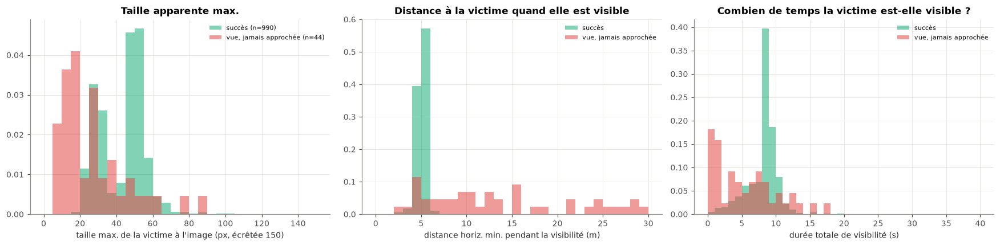

In [38]:
rows = []
for _, r in epx[epx["first_visible_t"].notna()].iterrows():
    tr = sd.load_traj(RUN_A, r["group"], r["seed"])
    if tr is None: continue
    v = tr["vis"] == 1
    if not v.any(): continue
    rows.append(dict(outcome=r["outcome"], ok=not r["fail"], px_max=np.nanmax(tr["vis_px"][v]),
                     hd_min_vis=np.nanmin(tr["hdist"][v]), vis_s=v.sum() * 5 * 0.02, lying=r["victim_lying"]))
vd = pd.DataFrame(rows)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
grp = [("succès", vd["ok"], SUCC_C), ("vue, jamais approchée", vd["outcome"] == "to_seen_not_close", FAIL_C)]
for lab, m, col in grp:
    ax[0].hist(vd.loc[m, "px_max"].clip(upper=150), bins=np.linspace(0, 150, 31), density=True, alpha=0.55, color=col, label=f"{lab} (n={m.sum()})")
    ax[1].hist(vd.loc[m, "hd_min_vis"].clip(upper=30), bins=np.linspace(0, 30, 31), density=True, alpha=0.55, color=col, label=lab)
    ax[2].hist(vd.loc[m, "vis_s"].clip(upper=40), bins=np.linspace(0, 40, 41), density=True, alpha=0.55, color=col, label=lab)
ax[0].set_xlabel("taille max. de la victime à l'image (px, écrêtée 150)"); ax[0].set_title("Taille apparente max.")
ax[1].set_xlabel("distance horiz. min. pendant la visibilité (m)"); ax[1].set_title("Distance à la victime quand elle est visible")
ax[2].set_xlabel("durée totale de visibilité (s)"); ax[2].set_title("Combien de temps la victime est-elle visible ?")
for a in ax: a.legend(fontsize=7)
fig.tight_layout(); save(fig, "16_seen_not_detected")
vd.groupby("outcome")[["px_max", "hd_min_vis", "vis_s"]].median().round(2)

> **Lecture.** Pour les seeds « vue, jamais approchée », la victime reste petite et lointaine, puis
> sort du champ. Le seuil d'engagement de la politique n'est pas atteint. Deux leviers à tester :
> (1) une **mémoire de détection** qui retient la position estimée de la victime et y retourne
> quand le signal disparaît ; (2) un **ralentissement / lacet vers la direction** de la détection
> faible pour la confirmer. C'est le plus gros gisement (+0.039 au plus).

### 16.4 Benchmark officiel : coût et score par type

,n,score,succes,wall_moy,sim_moy
env_type,,,,,
city,184,0.956,0.962,80.471,29.763
open,184,1.000,1.000,68.071,24.144
mountain,184,0.780,0.793,177.566,39.233
village,190,0.897,0.911,80.122,26.202
warehouse,182,0.879,0.896,94.860,21.538
forest,176,0.835,0.852,112.230,26.649


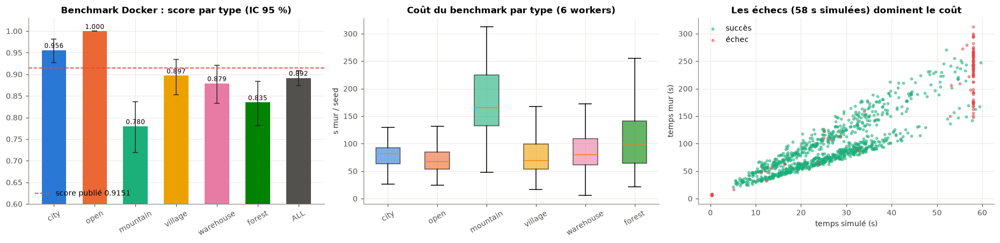

In [39]:
if BENCH_A is not None and Path(BENCH_A).exists():
    bm = sd.load_benchmark(BENCH_A)
    bm["fail"] = ~bm["success"].astype(bool)
    fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
    rows = []
    for t in TYPES + ["ALL"]:
        g = bm if t == "ALL" else bm[bm["env_type"] == t]
        m_, lo_, hi_ = sd.bootstrap_mean_ci(g["score"]); rows.append((t, m_, lo_, hi_, len(g)))
    bs = pd.DataFrame(rows, columns=["t", "m", "lo", "hi", "n"])
    xx = np.arange(len(bs))
    ax[0].bar(xx, bs["m"], color=[TC.get(t, "#52514e") for t in bs["t"]], width=0.6)
    ax[0].errorbar(xx, bs["m"], yerr=[bs["m"] - bs["lo"], bs["hi"] - bs["m"]], fmt="none", ecolor="#2b2b29", capsize=3, lw=1)
    ax[0].axhline(0.9151, color=FAIL_C, ls="--", lw=1.2, label="score publié 0.9151")
    for xi, v in zip(xx, bs["m"]): ax[0].text(xi, v + 0.005, f"{v:.3f}", ha="center", fontsize=8)
    ax[0].set_xticks(xx, bs["t"], rotation=30); ax[0].set_ylim(0.6, 1.03); ax[0].legend(loc="lower left")
    ax[0].set_title("Benchmark Docker : score par type (IC 95 %)")
    d = [bm.loc[bm["env_type"] == t, "wall_time"] for t in TYPES]
    bp = ax[1].boxplot(d, tick_labels=TYPES, patch_artist=True, showfliers=False)
    for p, t in zip(bp["boxes"], TYPES): p.set_facecolor(TC[t]); p.set_alpha(0.6)
    ax[1].set_ylabel("s mur / seed"); ax[1].set_title("Coût du benchmark par type (6 workers)"); ax[1].tick_params(axis="x", rotation=30)
    for ok, col, lab in [(True, SUCC_C, "succès"), (False, FAIL_C, "échec")]:
        g = bm[bm["fail"] != ok]
        ax[2].scatter(g["sim_time"], g["wall_time"], s=8, alpha=0.5, color=col, label=lab)
    ax[2].set_xlabel("temps simulé (s)"); ax[2].set_ylabel("temps mur (s)"); ax[2].legend()
    ax[2].set_title("Les échecs (58 s simulées) dominent le coût")
    fig.tight_layout(); save(fig, "16_bench")
    display(bm.groupby("env_type", observed=True).agg(n=("seed", "size"), score=("score", "mean"), succes=("success", "mean"),
            wall_moy=("wall_time", "mean"), sim_moy=("sim_time", "mean")).round(3))

### 16.5 Cascade des gains (bornes supérieures)

,poste,gain_max
0,décollage warehouse,0.006
1,< 2 m sans prédicat (trop haut),0.009
2,"vue, jamais approchée",0.039
3,jamais vue (recherche),0.026
4,autres crashs,0.013
5,infaisable / instable,0.004
6,terme temps,0.006
7,terme sécurité,0.005


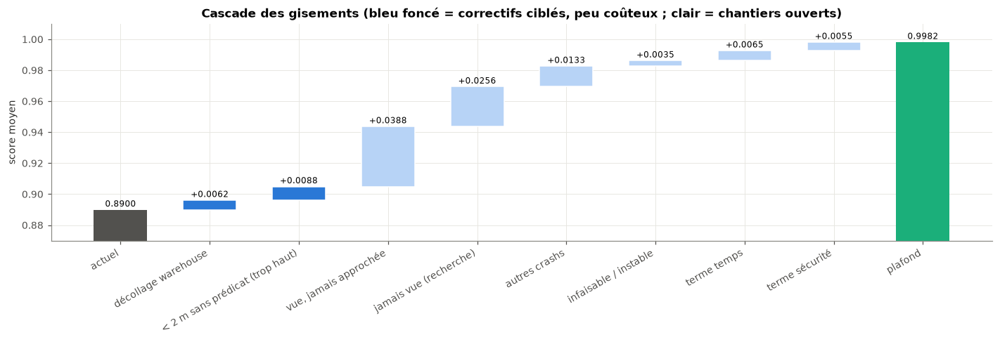

In [40]:
s0 = ep["score"].mean()
steps = [("score actuel", s0)]
smt = ep[~ep["fail"]].groupby("env_type", observed=True)["score"].mean()
def gain(mask):
    g = ep[mask]
    return sum(smt.get(t, 0.95) - s for t, s in zip(g["env_type"], g["score"])) / len(ep)
wh_take = (ep["env_type"] == "warehouse") & (ep["outcome"] == "crash") & (ep["sim_time"] < 1)
items = [("décollage warehouse", wh_take),
         ("< 2 m sans prédicat (trop haut)", ep["outcome"] == "to_close_no_pred"),
         ("vue, jamais approchée", ep["outcome"] == "to_seen_not_close"),
         ("jamais vue (recherche)", ep["outcome"] == "to_never_seen"),
         ("autres crashs", (ep["outcome"] == "crash") & ~wh_take),
         ("infaisable / instable", ep["outcome"].isin(["infeasible", "to_pred_unstable"]))]
vals = [(lab, gain(m)) for lab, m in items]
vals += [("terme temps", ep["loss_time"].sum() / len(ep)), ("terme sécurité", ep["loss_safety"].sum() / len(ep))]
fig, ax = plt.subplots(figsize=(13, 4.5))
cur = s0
ax.bar(0, s0, color="#52514e", width=0.6); ax.text(0, s0 + 0.002, f"{s0:.4f}", ha="center", fontsize=8)
for i, (lab, v) in enumerate(vals, 1):
    ax.bar(i, v, bottom=cur, color="#2a78d6" if i <= 2 else "#b7d3f6", width=0.6, edgecolor="white")
    ax.text(i, cur + v + 0.002, f"+{v:.4f}", ha="center", fontsize=8)
    cur += v
ax.bar(len(vals) + 1, cur, color="#1baf7a", width=0.6); ax.text(len(vals) + 1, cur + 0.002, f"{cur:.4f}", ha="center", fontsize=8)
ax.set_xticks(range(len(vals) + 2), ["actuel"] + [l for l, _ in vals] + ["plafond"], rotation=30, ha="right")
ax.set_ylim(s0 - 0.02, 1.01); ax.set_ylabel("score moyen")
ax.set_title("Cascade des gisements (bleu foncé = correctifs ciblés, peu coûteux ; clair = chantiers ouverts)")
fig.tight_layout(); save(fig, "16_waterfall")
pd.DataFrame(vals, columns=["poste", "gain_max"]).round(4)

> **Lecture.** Les deux correctifs ciblés (décollage warehouse, descente près de la victime)
> rapportent ensemble au plus environ +0.015. Ils sont rapides à valider : seeds identifiées et
> simulateur déterministe hors city. Le gros du gisement (+0.065) demande de travailler la
> perception et la recherche (vue sans approche, jamais vue). Il faut l'attaquer avec des A/B
> appariés sur les 1 100 seeds, ou sur le sous-ensemble mountain/forest pour itérer plus vite.

## 17. Correctifs : agent_v1 (3 oct. 2026)

`analysis/fixes/agent_v1/` = champion + deux correctifs ciblés, désactivables par variable d'environnement
(`KT_TKO=0` pour le fix 1, `KT_TDESC=0` pour le fix 2).

- **Fix 1 (warehouse, décollage).** Au premier pas, si z ≈ 0.191 m et que le haut de l'image de profondeur
  (lignes 0:16) voit un obstacle à ≤ 0.6 m, l'agent force l'`_Escape` (désactivé en warehouse dans le champion).
- **Fix 2 (mountain, descente sur verrou RGB).** La descente vers la cible verrouillée était plafonnée à
  0.45 m/s, et le minuteur « dud » (6 s) abandonnait la cible pendant la descente. La descente monte
  maintenant jusqu'à 1.5 m/s quand le drone est à moins de 1.6 m horizontalement, et le minuteur ne compte
  qu'une fois l'altitude de hover atteinte.

Validation sur de petits lots : les seeds en échec visées, plus des succès témoins du même type.

In [41]:
# Avant/après sur les seeds ciblées (mêmes seeds, simulateur déterministe hors city)
FIX_RUNS = {"ciblées": DATA / "v1_targeted", "témoins mountain": DATA / "v1_reg_mtn",
            "v2 verrou RGB": DATA / "v2_rgb"}   # agent_v2 = agent_v1 + verrou RGB assoupli
FIX = FIX_RUNS["ciblées"]
rows = []
for lot, p in FIX_RUNS.items():
    if not Path(p, "episodes.jsonl").exists():
        continue
    for _, r in sd.load_episodes(p).iterrows():
        a = ep[ep["seed"] == r["seed"]].iloc[0]
        rows.append(dict(lot=lot, seed=r["seed"], type=r["env_type"], avant=a["outcome"], score_avant=a["score"],
                         après=r["outcome"], score_après=r["score"], gain=r["score"] - a["score"]))
fx = pd.DataFrame(rows).sort_values(["lot", "type", "gain"], ascending=[True, True, False])
display(fx.round(3).reset_index(drop=True))
fxs = fx.groupby(["lot", "type"]).agg(n=("gain", "size"), score_avant=("score_avant", "mean"),
                                      score_après=("score_après", "mean"), gain_total=("gain", "sum"),
                                      récupérées=("gain", lambda g: int((g > 0.5).sum())),
                                      dégradées=("gain", lambda g: int((g < -1e-6).sum())))
display(fxs)
for lot, g in fx.groupby("lot", sort=False):
    print(f"{lot:18s} gain {g['gain'].sum():+.2f} pt sur {len(g)} seeds → {g['gain'].sum() / len(ep):+.4f} extrapolé sur {len(ep)} seeds")


,lot,seed,type,avant,score_avant,après,score_après,gain
0,ciblées,1000245,mountain,to_close_no_pred,0.010,success_fast,1.000,0.990
1,ciblées,1000238,mountain,to_close_no_pred,0.010,success_fast,1.000,0.990
2,ciblées,1000040,mountain,to_close_no_pred,0.010,success_slow,0.976,0.966
3,ciblées,1000616,mountain,to_close_no_pred,0.010,success_slow,0.742,0.732
4,ciblées,1000205,mountain,success_fast,1.000,success_fast,1.000,0.000
5,ciblées,1000490,mountain,success_fast,0.946,success_fast,0.946,0.000
6,ciblées,1000893,mountain,success_fast,0.900,success_fast,0.900,0.000
7,ciblées,1000949,mountain,success_fast,0.961,success_fast,0.961,0.000
8,ciblées,1001063,mountain,success_fast,0.903,success_fast,0.903,0.000
9,ciblées,1000193,warehouse,crash,0.010,success_fast,0.900,0.890


n  score_avant  score_après  gain_total  récupérées  dégradées
lot              type                                                                      
ciblées          mountain    9        0.528        0.936       3.678           4          0
                 warehouse   9        0.219        0.516       2.670           3          0
témoins mountain mountain   10        0.951        0.951       0.000           0          0
v2 verrou RGB    mountain   20        0.382        0.587       4.100           4          0

ciblées            gain +6.35 pt sur 18 seeds → +0.0058 extrapolé sur 1100 seeds
témoins mountain   gain +0.00 pt sur 10 seeds → +0.0000 extrapolé sur 1100 seeds
v2 verrou RGB      gain +4.10 pt sur 20 seeds → +0.0037 extrapolé sur 1100 seeds


### 17.1 Mountain 1000245 : avant / après

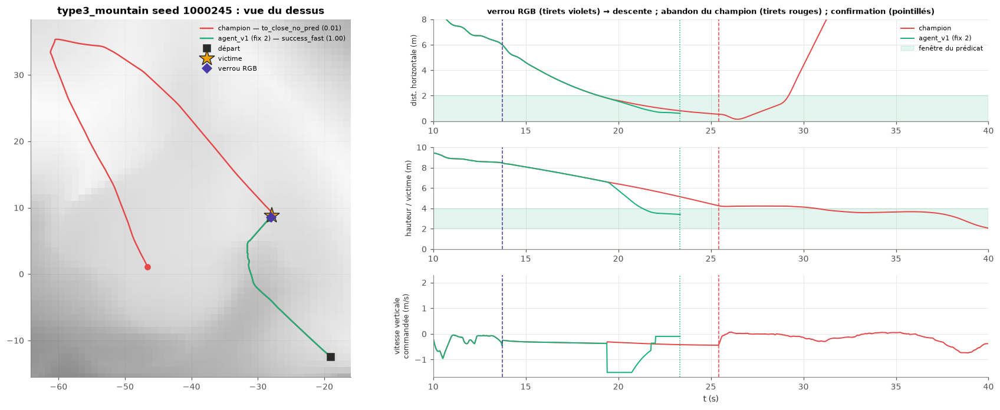

In [42]:
def fix_compare(group, seed, t_zoom=None, pad=14):
    ra = ep[(ep["group"] == group) & (ep["seed"] == seed)].iloc[0]
    rb = sd.load_episodes(FIX).query("seed == @seed").iloc[0]
    ta, tb = sd.load_traj(RUN_A, group, seed), sd.load_traj(FIX, group, seed)
    runs = [("champion", ta, ra, FAIL_C), ("agent_v1 (fix 2)", tb, rb, SUCC_C)]
    fig = plt.figure(figsize=(16, 6.4))
    gs = fig.add_gridspec(3, 2, width_ratios=[1, 1.35])
    a = fig.add_subplot(gs[:, 0])
    vx, vy = ra["victim_x"], ra["victim_y"]
    a.pcolormesh(ta["hm_x"], ta["hm_y"], ta["hm_z"], cmap="Greys", shading="auto", alpha=0.7)
    for lab, tr, r, c in runs:
        a.plot(tr["x"], tr["y"], color=c, lw=1.6, label=f"{lab} — {r['outcome']} ({r['score']:.2f})")
        a.plot(tr["x"][-1], tr["y"][-1], "o", color=c, ms=6)
    a.plot(ra["start_x"], ra["start_y"], "s", color="#2b2b29", ms=8, label="départ")
    a.plot(vx, vy, "*", color="#eda100", ms=18, mec="#2b2b29", label="victime")
    for e in ra["events"]:
        if e["kind"] == "rgb_latch":
            a.plot(e["value"][0], e["value"][1], "D", color="#4a3aa7", ms=7, label="verrou RGB")
    xs = np.r_[ta["x"], tb["x"], ra["start_x"]]; ys = np.r_[ta["y"], tb["y"], ra["start_y"]]
    a.set_xlim(xs.min() - 3, xs.max() + 3); a.set_ylim(ys.min() - 3, ys.max() + 3)
    a.set_aspect("equal"); a.legend(fontsize=7, loc="best")
    a.set_title(f"{group} seed {seed} : vue du dessus")
    ev = lambda r, k: next((e["t"] for e in r["events"] if e["kind"] == k), None)
    t_lat, t_unl = ev(ra, "rgb_latch"), ev(ra, "rgb_unlatch")
    spec = [("hdist", "dist. horizontale (m)", (0, 2)), ("h_above", "hauteur / victime (m)", (2, 4)),
            ("vz_cmd", "vitesse verticale\ncommandée (m/s)", None)]
    for k, (col, lab, band) in enumerate(spec):
        ax = fig.add_subplot(gs[k, 1])
        for name, tr, r, c in runs:
            y = tr["a_dz"] * tr["a_speed"] * 3 if col == "vz_cmd" else tr[col]
            ax.plot(tr["t"], y, color=c, lw=1.3, label=name)
            if r["t_confirm"] == r["t_confirm"] and r["t_confirm"] is not None:
                ax.axvline(r["t_confirm"], color=c, ls=":", lw=1)
        if band: ax.axhspan(*band, color=SUCC_C, alpha=0.12, label="fenêtre du prédicat")
        if t_lat: ax.axvline(t_lat, color="#4a3aa7", lw=1, ls="--")
        if t_unl: ax.axvline(t_unl, color=FAIL_C, lw=1, ls="--")
        if t_zoom: ax.set_xlim(*t_zoom)
        ax.set_ylabel(lab, fontsize=8)
        if col == "hdist": ax.set_ylim(0, 8)
        if col == "h_above": ax.set_ylim(0, 10)
        if k == 0:
            ax.legend(fontsize=7, loc="upper right")
            ax.set_title("verrou RGB (tirets violets) → descente ; abandon du champion (tirets rouges) ; "
                         "confirmation (pointillés)", fontsize=8.5)
    ax.set_xlabel("t (s)")
    fig.tight_layout()
    return fig


f = fix_compare("type3_mountain", 1000245, t_zoom=(10, 40))
save(f, "17_fix2_mountain_1000245"); plt.show()


> **Lecture.** Les deux trajectoires sont identiques jusqu'à t ≈ 19 s. Le verrou RGB tombe à t = 13.7 s
> (erreur 0.23 m). Le champion descend ensuite à 0.3–0.4 m/s : à t = 25.4 s, il est à 0.5 m horizontalement
> mais encore à 4.2 m au-dessus de la victime, soit 0.2 m au-dessus de la fenêtre du prédicat. Le minuteur
> « dud » expire à ce moment, la cible est abandonnée et le drone repart chercher ailleurs jusqu'au timeout.
> Avec le fix 2, la descente passe à 1.5 m/s dès que le drone est au-dessus de la cible : il entre dans la
> fenêtre 2–4 m à t ≈ 21 s et confirme à t = 23.3 s (score 1.00).

### 17.2 Warehouse 1000193 : décollage

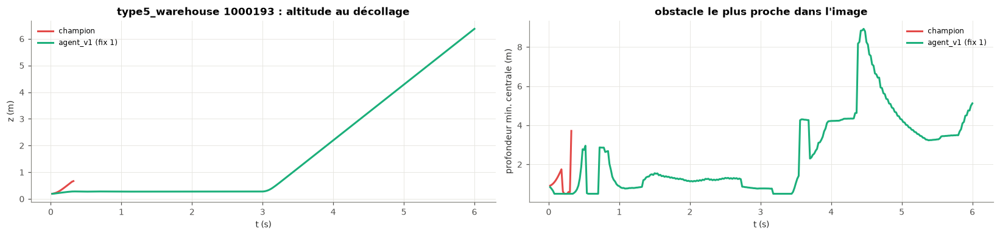

In [43]:
# Warehouse 1000193 : décollage sous une étagère (fix 1)
g, s = "type5_warehouse", 1000193
ta, tb = sd.load_traj(RUN_A, g, s), sd.load_traj(FIX, g, s)
if ta is not None and tb is not None:
    fig, ax = plt.subplots(1, 2, figsize=(15, 3.6))
    for name, tr, c in [("champion", ta, FAIL_C), ("agent_v1 (fix 1)", tb, SUCC_C)]:
        m = tr["t"] <= 6
        ax[0].plot(tr["t"][m], tr["z"][m], color=c, label=name)
        ax[1].plot(tr["t"][m], tr["depth_min_c"][m], color=c, label=name)
    ax[0].set_ylabel("z (m)"); ax[0].set_title(f"{g} {s} : altitude au décollage")
    ax[1].set_ylabel("profondeur min. centrale (m)"); ax[1].set_title("obstacle le plus proche dans l'image")
    for a in ax: a.set_xlabel("t (s)"); a.legend(fontsize=8)
    fig.tight_layout(); save(fig, "17_fix1_warehouse_1000193"); plt.show()


> **Lecture.** Le champion monte verticalement et percute l'étagère au-dessus de lui en 0.3 s. Avec le fix 1,
> l'escape le garde au ras du sol pendant 3 s (balayage, puis avance pour sortir de sous l'étagère),
> puis il monte, reprend la route normale et réussit (0.90).
>
> **Bilan.** 7 échecs récupérés sur 11 visés (4/4 en mountain, 3/7 en warehouse) et aucun des 17 succès
> témoins dégradé : +6.35 pts, soit environ **+0.006** extrapolé sur 1 100 seeds. Les 4 crashs warehouse restants sont
> soit invisibles pour la profondeur (étagère hors champ), soit dos au mur ; le recul et le balayage long ont
> été testés et sont pires.

### 17.3 agent_v2 : verrou RGB assoupli

Une sonde (`analysis/fixes/probe_rgb/`, script `analyse_probe_rgb.py`) a enregistré la sortie brute du
détecteur RGB sur 443 images de 12 échecs mountain « vue sans approche ». Parmi les 27 détections à
p ≥ 0.5, 24 sont vraies (erreur de position < 3 m). Le filtre `h > 1.0` en rejetait 17, et le plafond de
profondeur à 20 m en rejetait 3 ; les 3 acceptées étaient isolées, donc sans verrou. Les 3 fausses ont
toutes une profondeur au pixel ≥ 26.8 m.

`agent_v2` : `RP_HMAX` 1.0 → 2.0, profondeur max 20 → 25 m, verrou dès une détection à p ≥ 0.95
(`KT_RP_HMAX`, `KT_RP_RANGE`, `KT_RP_ONE`).

> **Lecture.** 4 échecs sur 12 récupérés (1000226 et 1000363 → 1.00, 1000640 → 0.89, 1000536 → 0.81),
> aucun témoin dégradé et un témoin amélioré (1000614 : 0.57 → 1.00) : +4.10 pts sur 20 seeds. Les 4 témoins
> qui réussissaient sans verrou verrouillent maintenant, avec le même score. Les échecs restants verrouillent
> trop tard (après 49 s) ou ne détectent rien : c'est la recherche qu'il faut améliorer. À confirmer sur les
> 184 seeds mountain.

In [44]:
# Export des tables pour le rapport
out = HERE / "tables"; out.mkdir(exist_ok=True)
ov.to_csv(out / "overview_by_type.csv"); loss.to_csv(out / "loss_by_type.csv"); prio.to_csv(out / "priorities.csv", index=False)
ep[ep["fail"]].drop(columns=[c for c in ["events", "route_codes", "esc_codes", "traceback"] if c in ep]).to_csv(out / "failed_seeds.csv", index=False)
if HAS_TRAJ: epx.drop(columns=[c for c in ["events", "route_codes", "esc_codes", "traceback"] if c in epx]).to_csv(out / "episodes_with_features.csv", index=False)
print("tables écrites dans", out, "— figures dans", FIG_DIR)

tables écrites dans D:\projets IA\SWARM\sar-task\analysis\diagnostic\tables — figures dans D:\projets IA\SWARM\sar-task\analysis\diagnostic\figures


## 18. Résultat final : benchmark officiel agent_final vs champion (5 oct. 2026)

`agent_final` (`analysis/agent_final/`, = agent_v6) = champion + correctifs fix 1, fix 2, verrou RGB assoupli,
plafond d'AGL en mountain et balayage vertical. Les deux agents passent le **même** `swarm benchmark` Docker sur les
**mêmes 1 100 seeds**. Comparaison appariée seed par seed, IC 95 % par bootstrap (10 000 tirages).


,n,champion,agent_final,delta,ci_lo,ci_hi,récupérées,perdues
type,,,,,,,,
city,184,0.956,0.952,-0.004,-2.210e-02,0.012,1,2
open,184,1.000,1.000,0.000,0.000e+00,0.000,0,0
mountain,184,0.780,0.842,0.062,1.910e-02,0.108,17,4
village,190,0.897,0.897,0.000,0.000e+00,0.000,0,0
warehouse,182,0.879,0.893,0.014,-2.000e-04,0.034,3,0
forest,176,0.835,0.835,0.000,0.000e+00,0.000,0,0
TOTAL,1100,0.892,0.904,0.012,4.000e-03,0.021,21,6


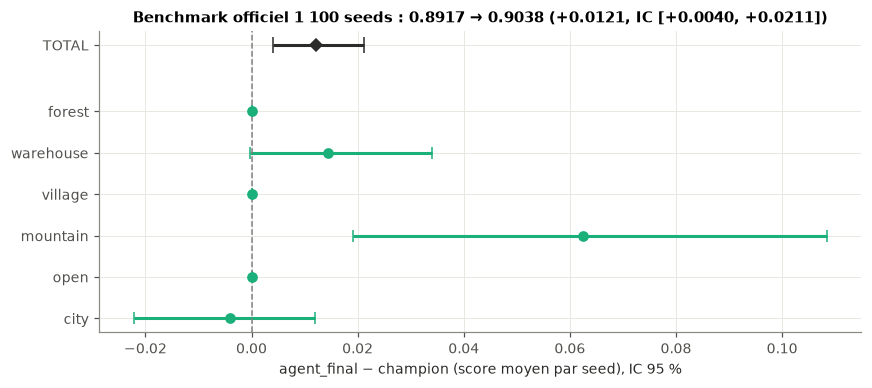

In [45]:
import json
BENCH_FINAL = DATA / "bench" / "bench_v6_full.json"

def bench_by_seed(path):
    d = json.loads(Path(path).read_text(encoding="utf-8"))
    return pd.DataFrame([r for g in d["group_results"].values() for r in g]).set_index("seed")

ca, cb = bench_by_seed(BENCH_A), bench_by_seed(BENCH_FINAL)
fin = ca[["group", "score", "success"]].join(cb[["score", "success"]], rsuffix="_final")
fin["delta"] = fin["score_final"] - fin["score"]
rng = np.random.default_rng(0)

def boot_ci(x, n=10_000):
    x = np.asarray(x)
    return np.percentile(rng.choice(x, (n, len(x))).mean(1), [2.5, 97.5])

rows = []
for name, g in list(fin.groupby("group")) + [("TOTAL", fin)]:
    lo, hi = boot_ci(g["delta"])
    rows.append(dict(type=name.replace("type", "").split("_")[-1] if name != "TOTAL" else "TOTAL", n=len(g),
                     champion=g["score"].mean(), agent_final=g["score_final"].mean(), delta=g["delta"].mean(),
                     ci_lo=lo, ci_hi=hi,
                     récupérées=int((g["success_final"] & ~g["success"]).sum()),
                     perdues=int((g["success"] & ~g["success_final"]).sum())))
res = pd.DataFrame(rows).set_index("type")
display(res.round(4))

fig, ax = plt.subplots(figsize=(8, 3.6))
r = res.drop("TOTAL")
y = np.arange(len(r))
ax.errorbar(r["delta"], y, xerr=[r["delta"] - r["ci_lo"], r["ci_hi"] - r["delta"]], fmt="o", color=SUCC_C, capsize=4)
t = res.loc["TOTAL"]
ax.errorbar([t["delta"]], [len(r) + 0.6], xerr=[[t["delta"] - t["ci_lo"]], [t["ci_hi"] - t["delta"]]],
            fmt="D", color="#2b2b29", capsize=5)
ax.set_yticks(list(y) + [len(r) + 0.6], list(r.index) + ["TOTAL"])
ax.axvline(0, color="grey", lw=1, ls="--")
ax.set_xlabel("agent_final − champion (score moyen par seed), IC 95 %")
ax.set_title(f"Benchmark officiel 1 100 seeds : {t['champion']:.4f} → {t['agent_final']:.4f} "
             f"({t['delta']:+.4f}, IC [{t['ci_lo']:+.4f}, {t['ci_hi']:+.4f}])", fontsize=10)
fig.tight_layout(); save(fig, "18_final_benchmark"); plt.show()
